# Fig 6, Ext Fig 8: Rewarded vs. Omission Trials and Time Warp models

Make sure to first clone and pip install the time warp model repo from Alex Williams:  \
https://github.com/ahwillia/affinewarp

Table of Contents

[Fit time warp model and compute reward vs. omission index](#Loop-omission-analysis-for-all-the-switch-animals-and-days)  \
[Save model output or load previously saved output](#Save-or-Load-previously-saved-model-outputs)

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import sys
import os
import dill
import numpy as np
import scipy as sp
import pandas as pd
import copy

from matplotlib import pyplot as plt
from matplotlib import cm
import seaborn as sns
sns.set_style("white")

from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import rewardAnalysis as ra
from reward_relative import behavior as behav
from itertools import combinations

import sklearn
import TwoPUtils

from affinewarp import ShiftWarping, PiecewiseWarping


save_figures = False

In [2]:
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [3]:
path_dict

{'preprocessed_root': '/data/2p_data',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2p_data/VR_Data',
 'git_repo_root': '/home/sosalab/local_repos',
 'TwoPUtils': '/home/sosalab/local_repos/TwoPUtils',
 'home': '/home/sosalab',
 'fig_dir': '/data/2p_data/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2p_data/fig_scratch/Mar2026


## Load saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multi_anim_sess',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))


/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


# Loop omission analysis for all the switch animals and days

Only proceed if n_omission trials in set0 (before switch) >= 3

[Load multiDayData](#Load-saved-multiDayData)


In [6]:
import seaborn as sns
sns.set_style('white')
pt.set_fig_params(fontsize=12)
import copy
from sklearn.impute import KNNImputer

### Run this cell to fit a new model and plot original and time-warped cells

NOTE! This model is stochastic and will not produce exactly the same result each time.

The swarm plots will not be __exactly__ as they appear in the paper since those figures  \
are from one particular run of the model (with the same parameters as below),  \
but they should be very similar.

Run this separately for either trial set 0 (before the switch) or 1 (after the switch).  \
I recommend saving the output after running (see code below)

GCAMP3 day 3: n omiss trials=8


Loss improvement: 65.10%: 100%|██████████| 50/50 [00:00<00:00, 421.37it/s]


best model= piecewise 3 knots
GCAMP4 day 3: n omiss trials=8


/home/sosalab/local_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
Loss improvement: 67.61%: 100%|██████████| 50/50 [00:00<00:00, 441.86it/s]


best model= piecewise 3 knots
GCAMP7 day 3: n omiss trials=10


...

Loss improvement: 86.61%: 100%|██████████| 50/50 [00:00<00:00, 402.42it/s]


best model= piecewise 3 knots
GCAMP19 day 3: n omiss trials=3


Loss improvement: 83.97%: 100%|██████████| 50/50 [00:00<00:00, 434.26it/s]


best model= piecewise 3 knots


KeyboardInterrupt: 

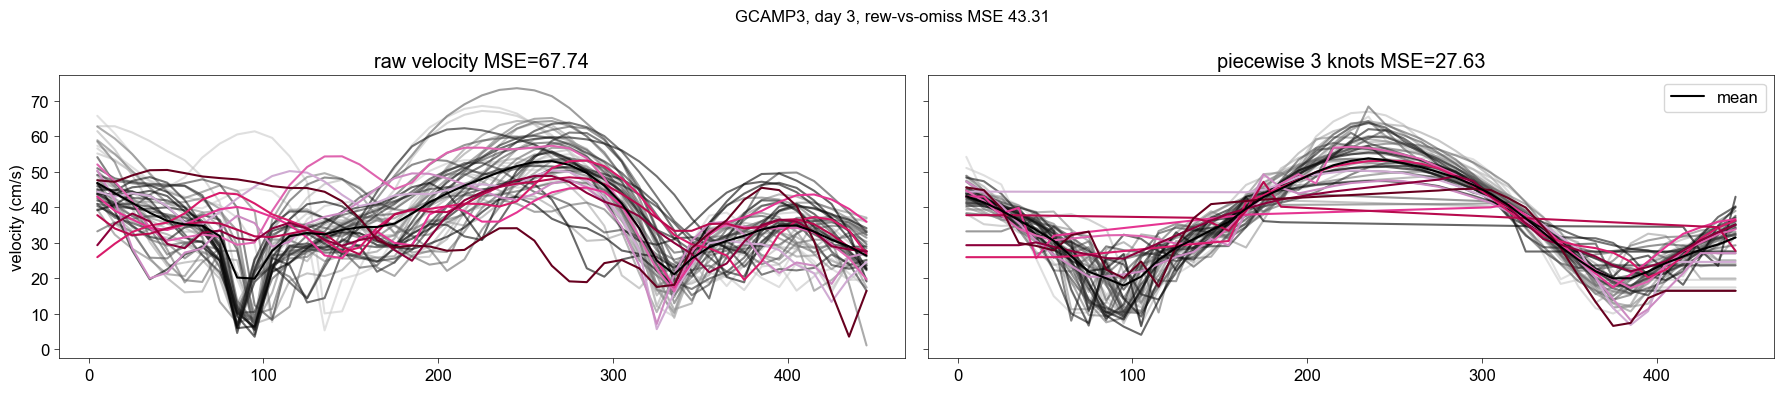

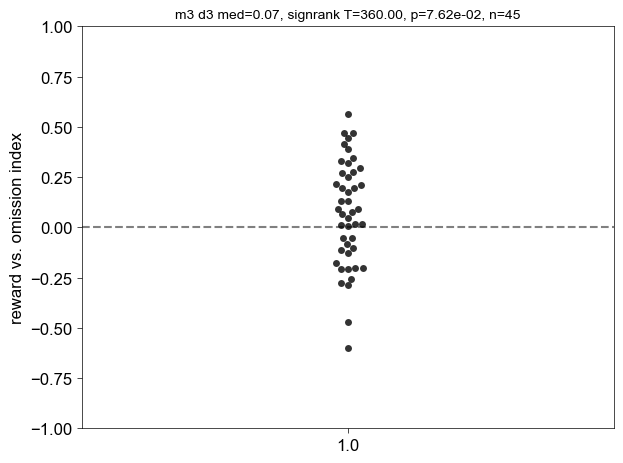

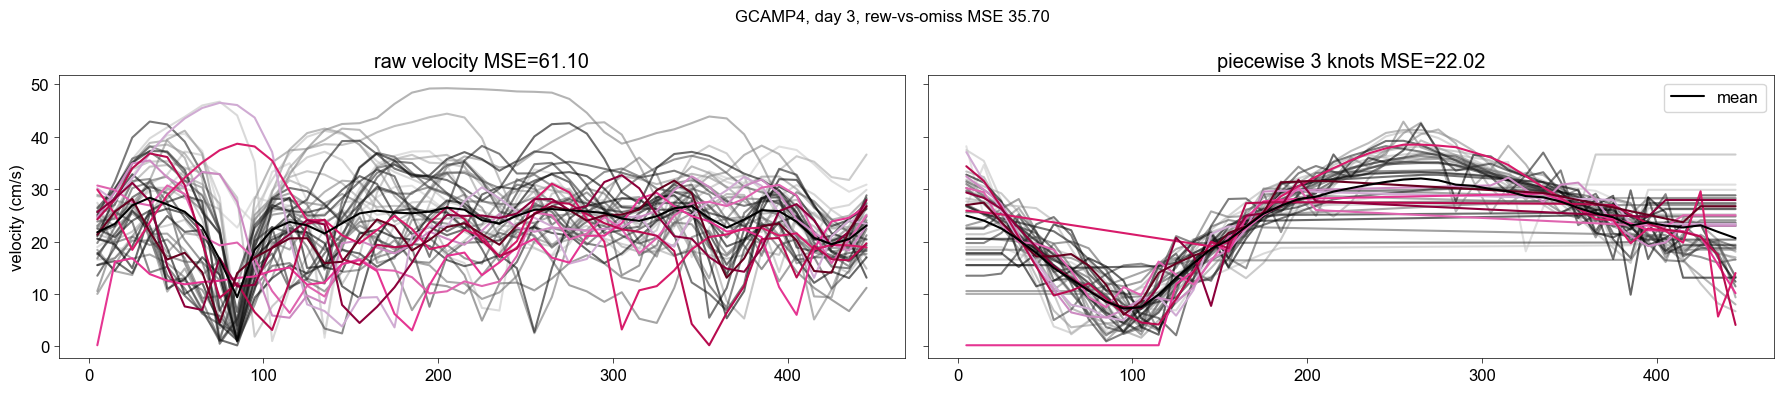

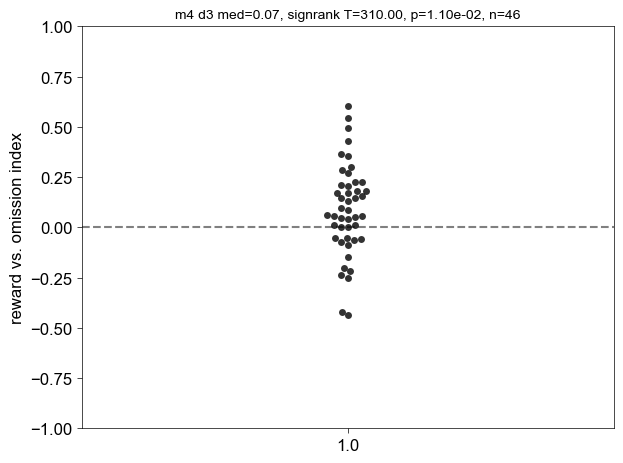

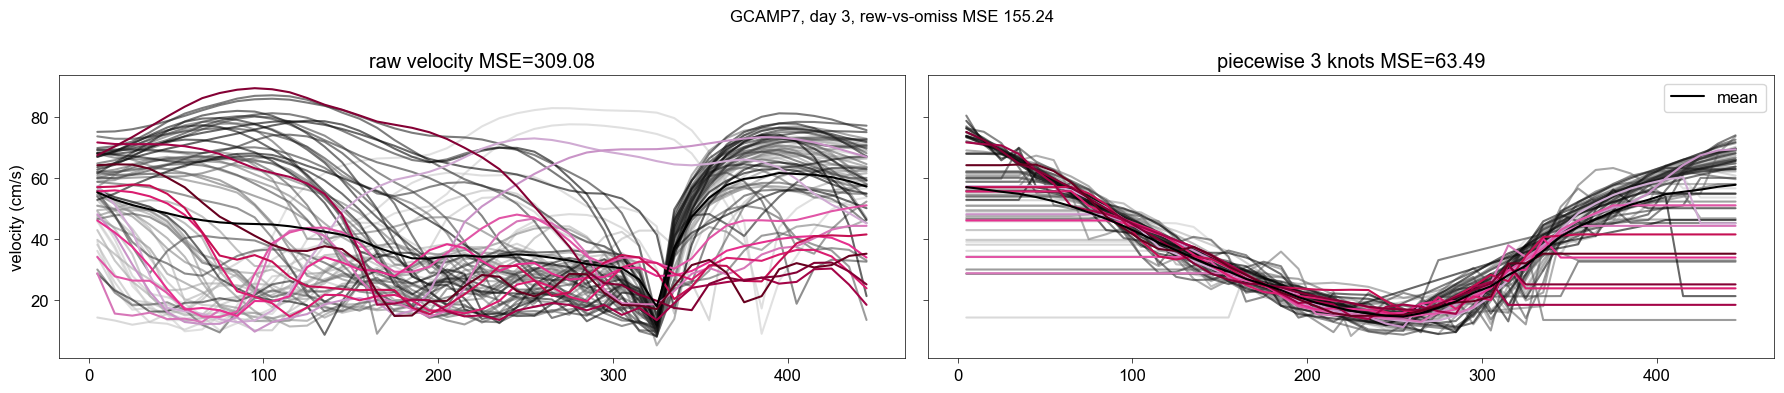

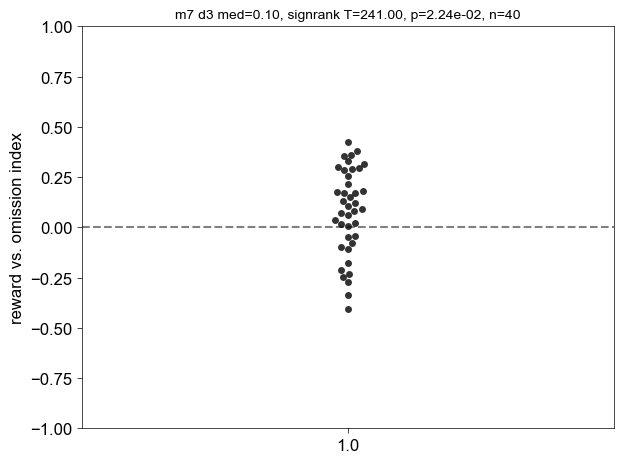

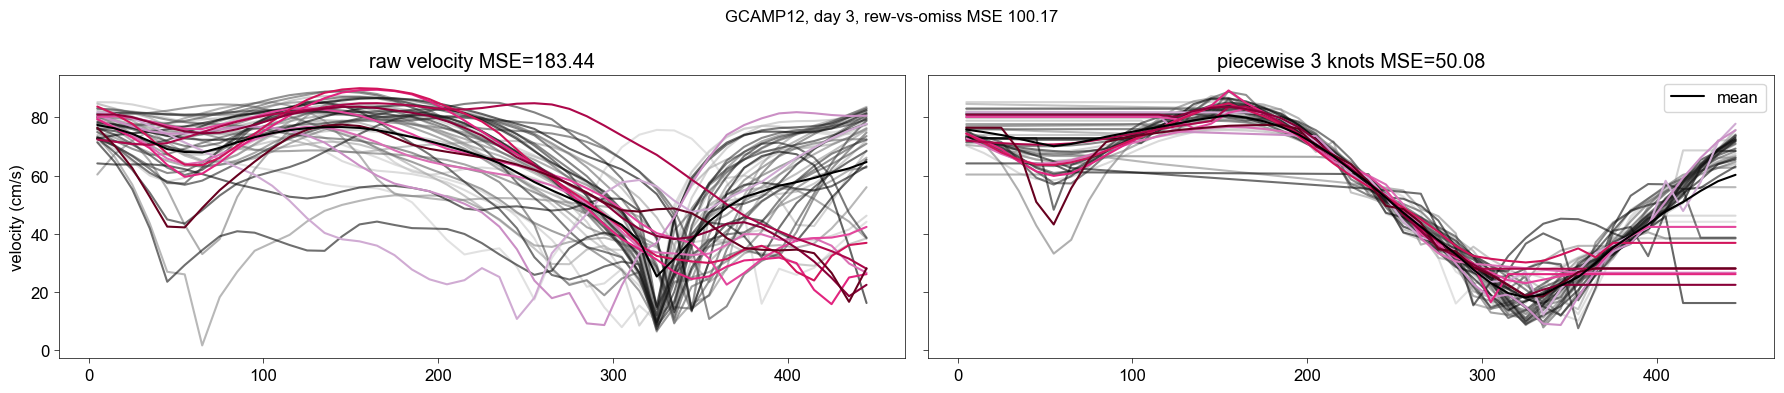

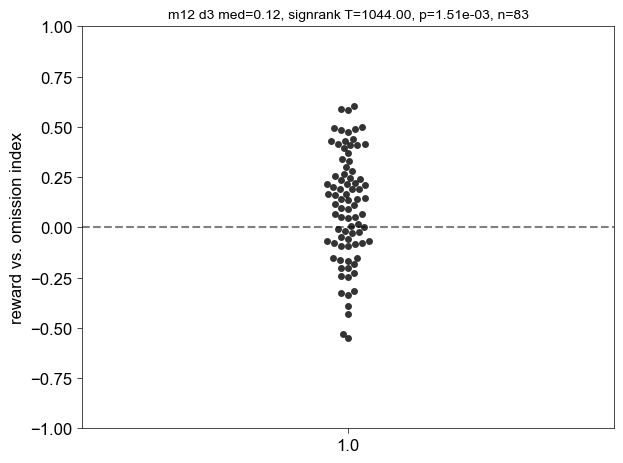

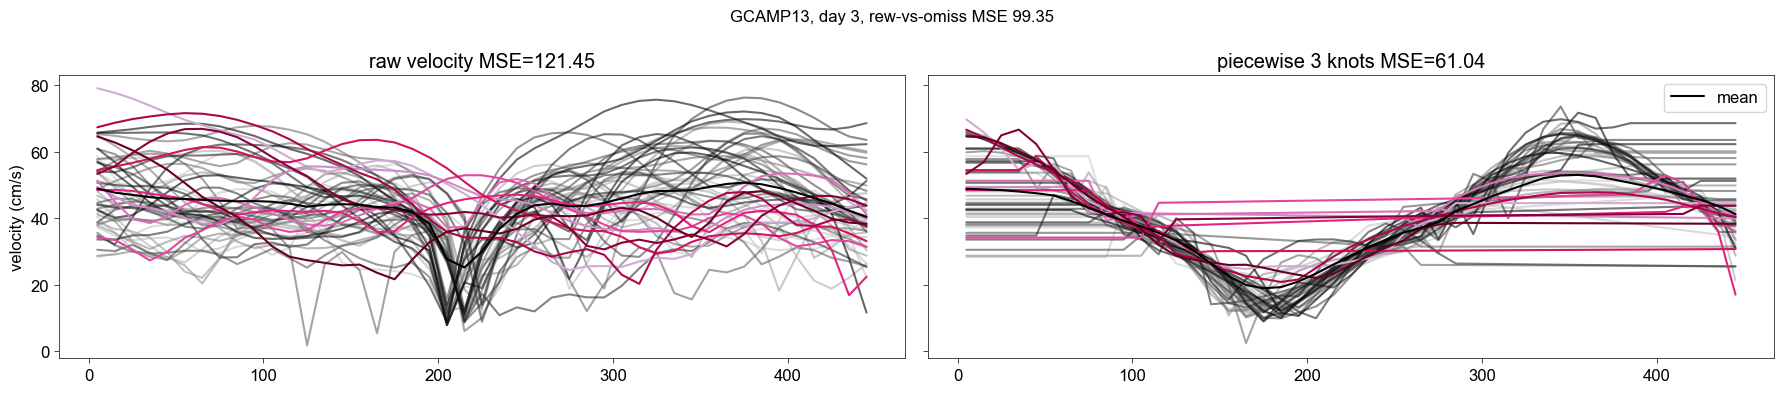

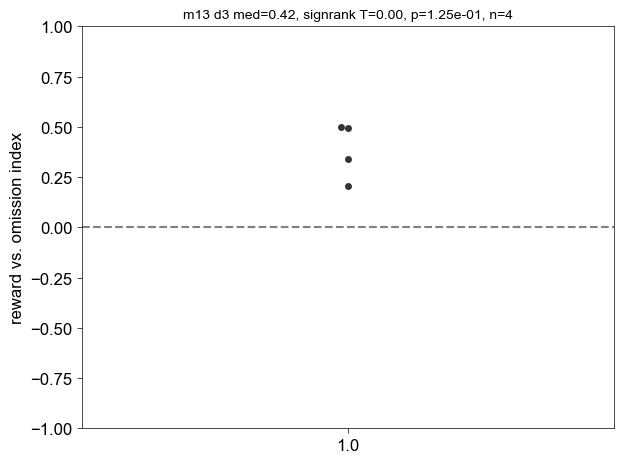

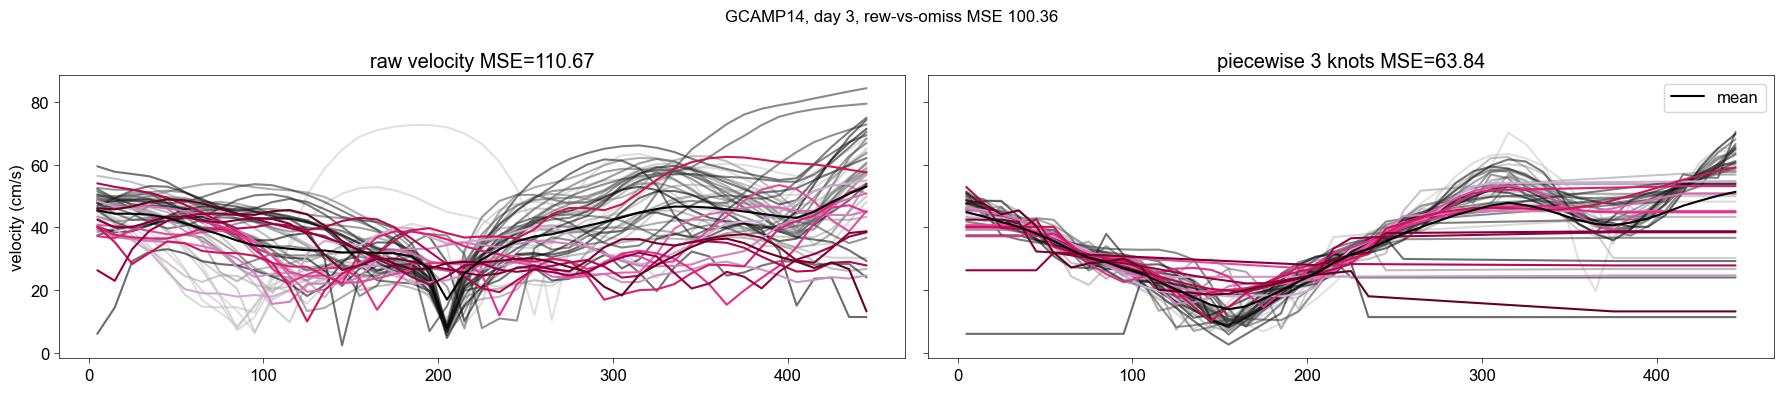

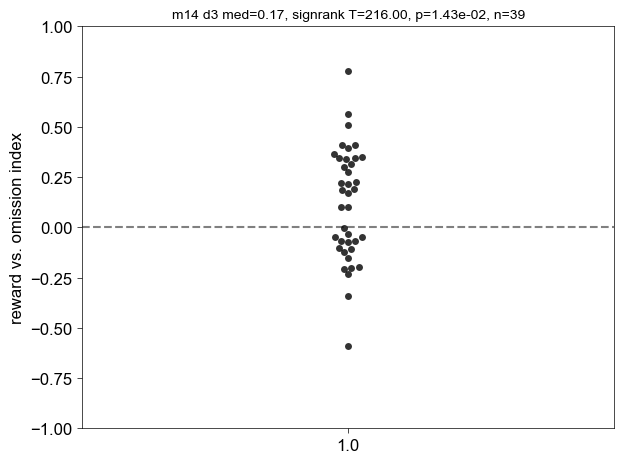

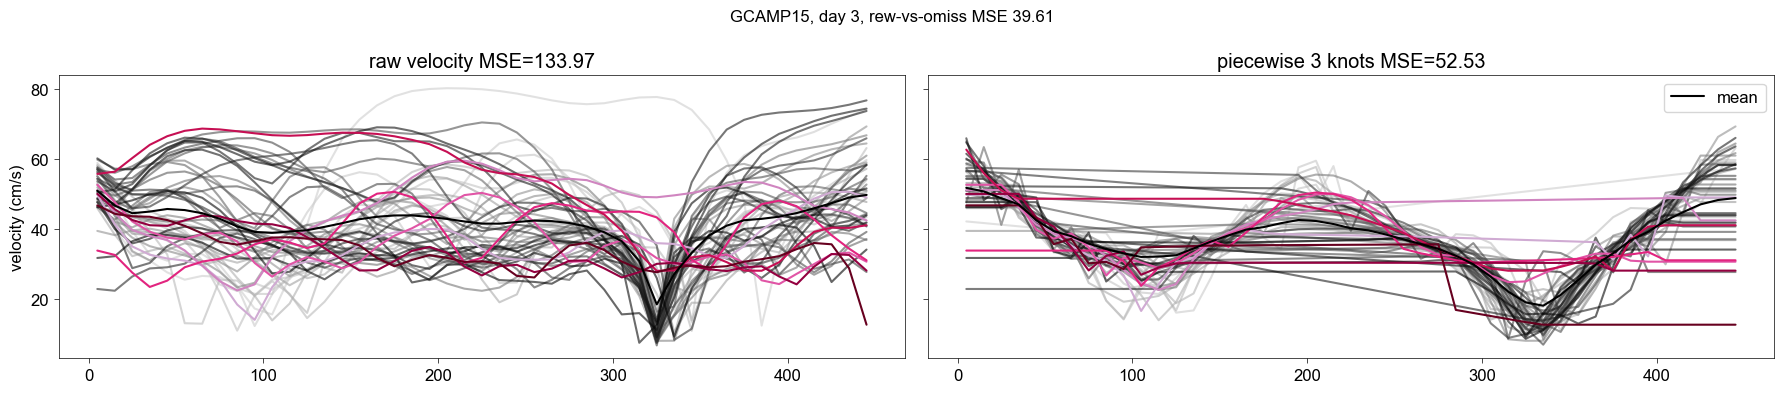

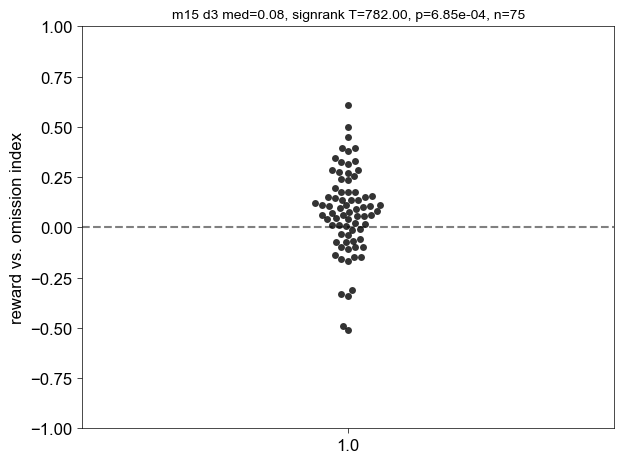

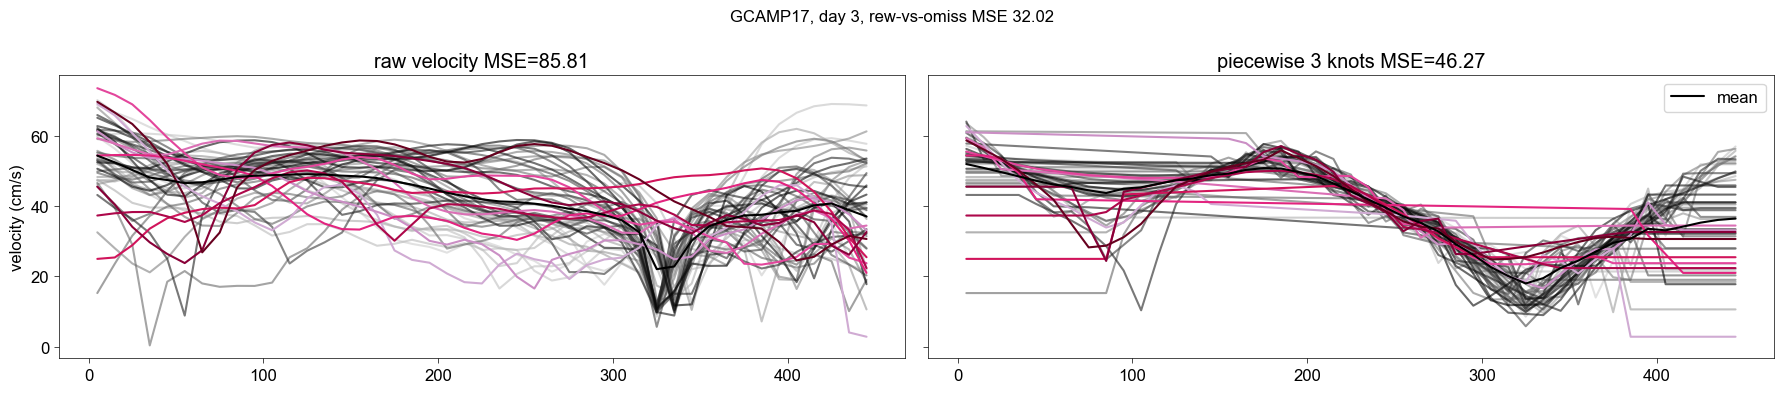

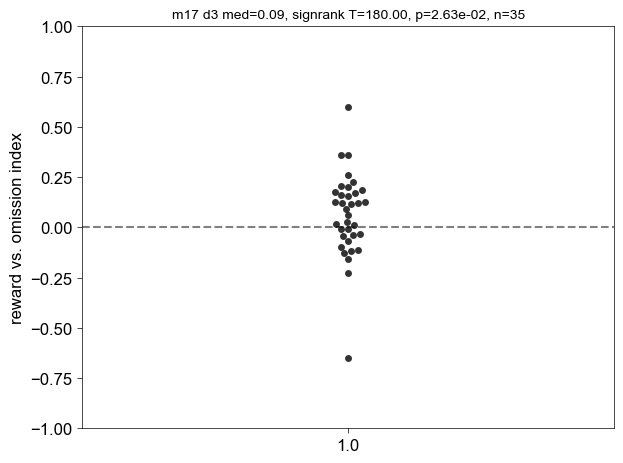

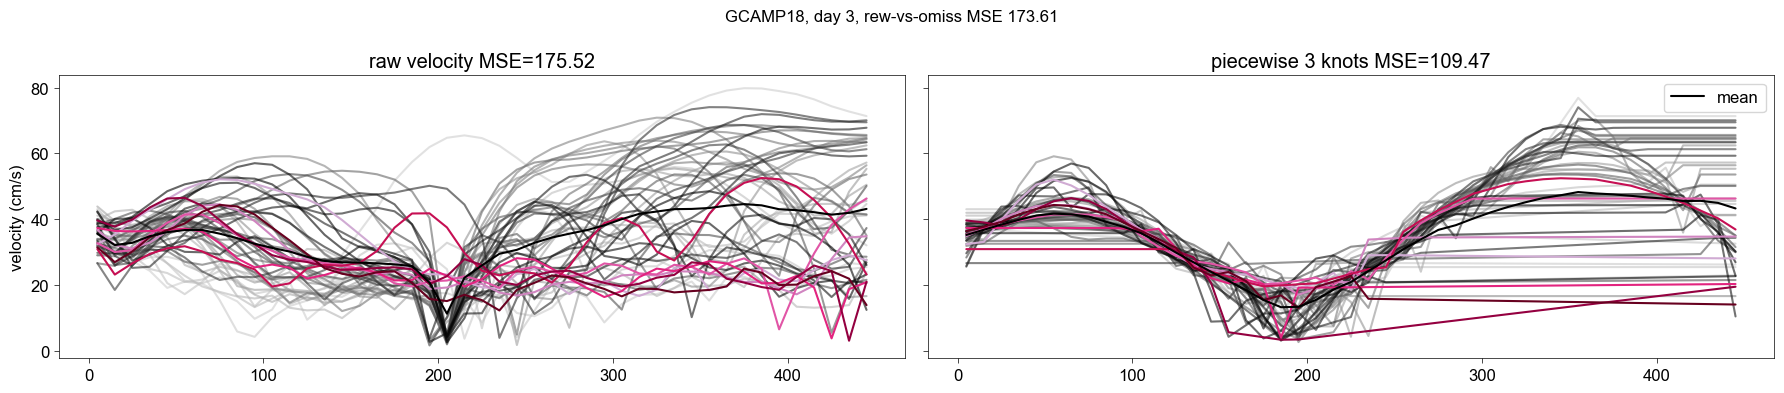

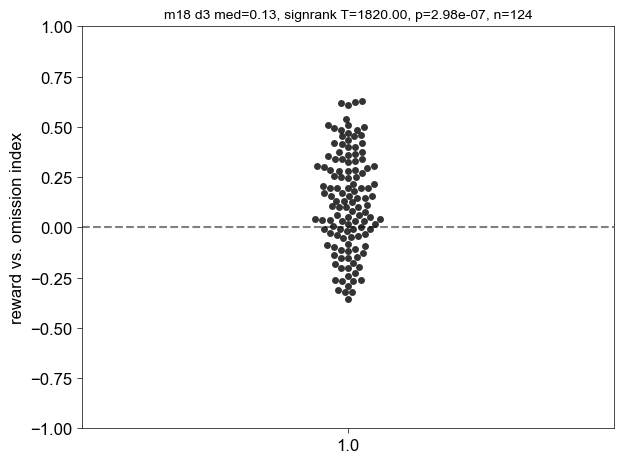

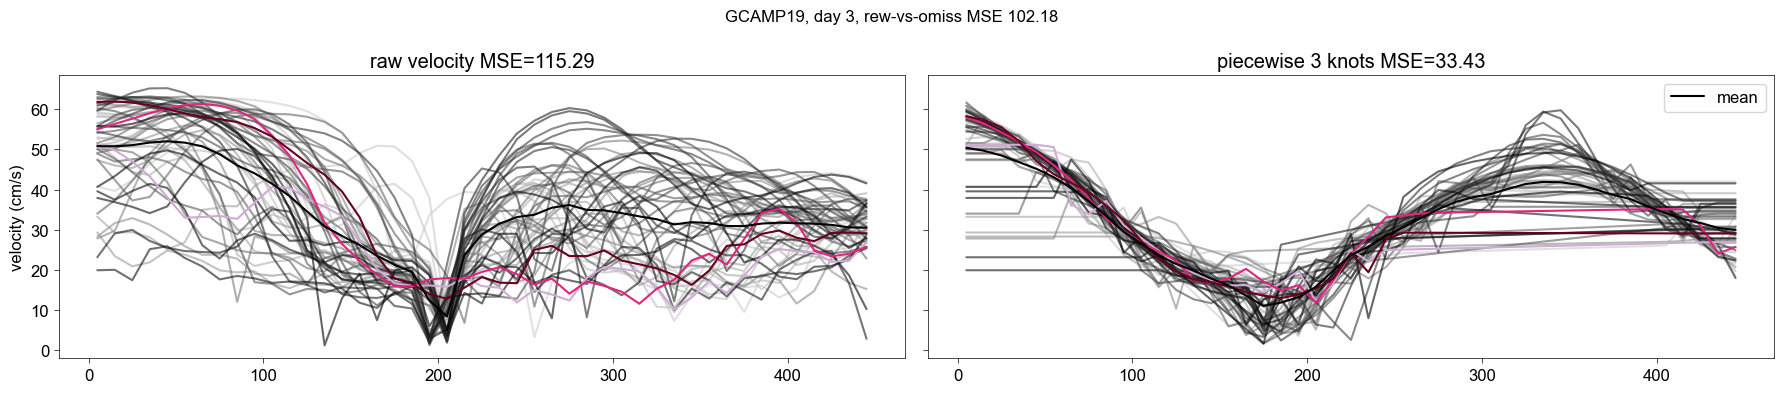

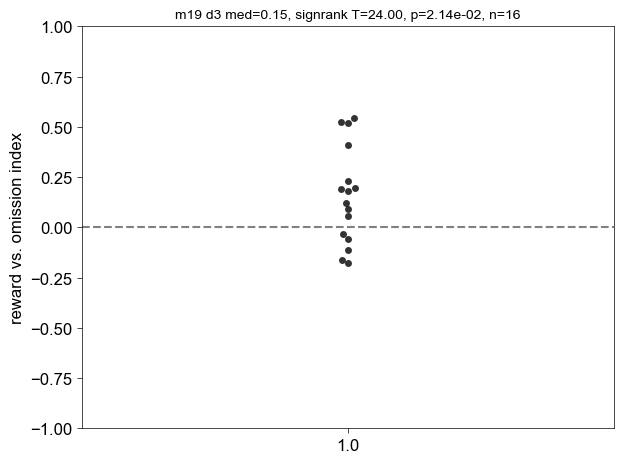

: 

In [ ]:
plot_speed = True


rew_vs_omiss_index = {} # RO index from model-transformed data
rew_vs_omiss_index_original = {} # RO index from original data, for comparison
rew_vs_omiss_vel_mse = {} 
exp_days = [3,5,7,8,10,12,14]
save_figures = False
plot_cells = False # Generates a lot of big plots

use_set = 'set 1' # which trial set to use for time warping

anim_to_calc = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']

for day in exp_days:
    
    # multi_anim_sess = ut.quick_load_multi_anim_sess(day)
    multi_anim_sess = dd.load_multi_anim_sess(path_dict, day, an_list=dd.define_anim_list(experiment,
                                                                                day,
                                                                                year='combined'),
                                                                    subdirs = ['multi_anim_sess'])

    rew_vs_omiss_index[day] = {}
    rew_vs_omiss_index_original[day] = {}
    rew_vs_omiss_vel_mse[day] = {}
    
    for an in anim_to_calc: #anim_list:

        ## find reward relative cells that fire after the reward location
        rel_dist_rr_0 = multiDayData[day].rel_peaks[an]['set 0'][
            (np.isin(np.where(multiDayData[day].overall_place_cell_masks[an])[0],
                multiDayData[day].reward_rel_cell_ids[an]))
        ]
        rel_dist_rr_1 = multiDayData[day].rel_peaks[an]['set 1'][
            (np.isin(np.where(multiDayData[day].overall_place_cell_masks[an])[0],
                multiDayData[day].reward_rel_cell_ids[an]))
        ]
        after_reward = multiDayData[day].reward_rel_cell_ids[an][rel_dist_rr_0 > 0]
        after_rr_mask = np.zeros((multiDayData[day].overall_place_cell_masks[an].shape), dtype=bool)
        after_rr_mask[after_reward] = True

        ## Find reward and omission trials
        sess = copy.deepcopy(multi_anim_sess[an]['sess'])
        isreward, _ = behav.get_trial_types(sess)
        isreward = isreward.astype(bool)
        # find omission trials
        omission = ra.get_omission_trials(sess)
        omiss_bool = np.zeros((len(isreward),),dtype=bool)
        omiss_bool[omission['trials']] = True

        # find which trials are before vs. after
        trial_dict = behav.define_trial_subsets(sess, force_two_sets=True)
        trial_set0 = trial_dict['trial_set0']
        trial_set1 = trial_dict['trial_set1']

        # booleans that are the length of the trial set
        rew_trials = {'set 0': np.multiply(isreward, trial_set0)[np.where(trial_set0)[0]],
                      'set 1': np.multiply(isreward, trial_set1)[np.where(trial_set1)[0]]
                     }

        omiss_trials = {'set 0': np.multiply(omiss_bool, trial_set0)[np.where(trial_set0)[0]],
                        'set 1': np.multiply(omiss_bool, trial_set1)[np.where(trial_set1)[0]]
                       }
        
        # trial IDs for indexing the whole session
        rew_trials_ID = {'set 0': np.where(np.multiply(isreward, trial_set0))[0],
                      'set 1': np.where(np.multiply(isreward, trial_set1))[0]
                     }

        omiss_trials_ID = {'set 0': np.where(np.multiply(omiss_bool, trial_set0))[0],
                        'set 1': np.where(np.multiply(omiss_bool, trial_set1))[0]
                       }

        n_omiss = np.sum(omiss_trials[use_set])
        print('%s day %d: n omiss trials=%d' % (an,day,n_omiss))
        
        # Check if at least 3 omission trials - otherwise skip this session
        if n_omiss<3:
            print('< 3 omission trials, skipping...')
            rew_vs_omiss_index[day][an] = {'cell_ids': after_reward,
                                               'RO_index': np.nan,
                                               'n_omiss': n_omiss,
                                               'best_model': np.nan,
                                              }
            rew_vs_omiss_index_original[day][an] = {'cell_ids': after_reward,
                                               'RO_index': np.nan,
                                              }
            continue
        else:
            
            # average activity on rewarded vs omission trials
            omiss_bin_centers = sess.trial_matrices['speed'][-1]
            use_ts_key = 'events'

            # compute trial matrix with slow times removed
            tm = TwoPUtils.spatial_analyses.trial_matrix(sess.timeseries[use_ts_key].T,
                                                            sess.vr_data['pos'].values,
                                                            sess.trial_start_inds,
                                                            sess.teleport_inds,
                                                            bin_size=10,
                                                            min_pos = 0,
                                                            max_pos= 450,
                                                            speed_thr = 2,
                                                            speed = sess.vr_data['speed'].values
                                                           )

            neural_data_in = {'set 0': tm[0][trial_set0][:,:,after_reward],
                              'set 1': tm[0][trial_set1][:,:,after_reward]
                             }
            
            speed_data_in = {'set 0': sess.trial_matrices['speed'][0][trial_set0,:],
                              'set 1': sess.trial_matrices['speed'][0][trial_set1,:]
                             }
            
            rewarded_means = {'set 0': np.zeros((len(after_reward),len(omiss_bin_centers))),
                              'set 1': np.zeros((len(after_reward),len(omiss_bin_centers))),
                             }
            omission_means = {'set 0': np.zeros((len(after_reward),len(omiss_bin_centers))),
                              'set 1': np.zeros((len(after_reward),len(omiss_bin_centers))),
                             }
            rewarded_sem = {'set 0': np.zeros((len(after_reward),len(omiss_bin_centers))),
                            'set 1': np.zeros((len(after_reward),len(omiss_bin_centers))),
                           }
            omission_sem = {'set 0': np.zeros((len(after_reward),len(omiss_bin_centers))),
                            'set 1': np.zeros((len(after_reward),len(omiss_bin_centers))),
                           }

            speed_rew_mean = {'set 0': np.zeros((len(omiss_bin_centers),)),
                          'set 1': np.zeros((len(omiss_bin_centers),)),
                         }
            speed_rew_sem = {'set 0': np.zeros((len(omiss_bin_centers),)),
                          'set 1': np.zeros((len(omiss_bin_centers),)),
                         }

            speed_omiss_mean = {'set 0': np.zeros((len(omiss_bin_centers),)),
                          'set 1': np.zeros((len(omiss_bin_centers),)),
                         }
            speed_omiss_sem = {'set 0': np.zeros((len(omiss_bin_centers),)),
                          'set 1': np.zeros((len(omiss_bin_centers),)),
                         }

            # Get trial by trial speed
            for s in ['set 0', 'set 1']:
                speed_rew_mean[s] = np.nanmean(sess.trial_matrices['speed'][0][rew_trials_ID[s],:],axis=0)
                speed_rew_sem[s] = ut.sem(sess.trial_matrices['speed'][0][rew_trials_ID[s],:],axis=0)
                speed_omiss_mean[s] = np.nanmean(sess.trial_matrices['speed'][0][omiss_trials_ID[s],:],axis=0)
                speed_omiss_sem[s] = ut.sem(sess.trial_matrices['speed'][0][omiss_trials_ID[s],:],axis=0)

                
            
            rew_vs_omiss_index_original[day][an]={'cell_ids': after_reward,
                                                 'RO_index': np.zeros((len(after_reward),))*np.nan,
                                                }
            
            # iterate through cells and assemble neural data to use
            for c_i, c in enumerate(after_reward):
                # normalize each cell to its session mean
                norm_this_cell = np.nanmean(tm[0][:,:,c].ravel())
                tmp_mat = tm[0][:,:,c] / norm_this_cell
                tmp_mat[np.isnan(tmp_mat)] = 0
                neural_data_in['set 0'][:,:,c_i] = tmp_mat[trial_set0]
                neural_data_in['set 1'][:,:,c_i] = tmp_mat[trial_set1]

                for s in ['set 0', 'set 1']:
                    rewarded_means[s][c_i,:] = np.nanmean(tmp_mat[rew_trials_ID[s],:],axis=0)
                    rewarded_sem[s][c_i,:] = ut.sem(tmp_mat[rew_trials_ID[s],:],axis=0)

                    omission_means[s][c_i,:] = np.nanmean(tmp_mat[omiss_trials_ID[s],:],axis=0)
                    omission_sem[s][c_i,:] = ut.sem(tmp_mat[omiss_trials_ID[s],:],axis=0)

                # collect the original reward vs. omission index before model transformation
                rew_mean_this_cell = np.nanmean(
                                neural_data_in[use_set][rew_trials[use_set]][:,:,c_i],
                                axis=0)
            
                omiss_mean_this_cell = np.nanmean(
                    neural_data_in[use_set][omiss_trials[use_set]][:,:,c_i],
                    axis=0)

                rew_vs_omiss_index_original[day][an]['RO_index'][c_i] = np.sum(
                    rew_mean_this_cell-omiss_mean_this_cell) / (
                np.sum(rew_mean_this_cell+omiss_mean_this_cell))

            # Get rid of nans in speed input data:
            if np.any(np.isnan(speed_data_in[use_set])):
                imputer = KNNImputer(n_neighbors=3)
                speed_data_in[use_set] = imputer.fit_transform(speed_data_in[use_set])

            ## Fit time warping model.

            ## Run this if you want to compare model types
            # models = [
            #     ShiftWarping(smoothness_reg_scale=20.0),
            #     PiecewiseWarping(n_knots=0, warp_reg_scale=1e-6, smoothness_reg_scale=20.0),
            #     PiecewiseWarping(n_knots=1, warp_reg_scale=1e-6, smoothness_reg_scale=20.0),
            #     PiecewiseWarping(n_knots=2, warp_reg_scale=1e-6, smoothness_reg_scale=20.0),
            #     PiecewiseWarping(n_knots=3, warp_reg_scale=1e-6, smoothness_reg_scale=20.0),
            # ]
            
            ## We selected piecewise-3 for all data after comparing the above models (Ext Fig. 8)
            models = [
                PiecewiseWarping(n_knots=3, warp_reg_scale=1e-6, smoothness_reg_scale=20.0),
            ]
          
            for m in models:
                m.fit(np.expand_dims(speed_data_in[use_set], axis=2), iterations=50, warp_iterations=200)

            # Plot mean and individual velocity traces, with summed squared residual
            transformed_neural = {}
            transformed_vel = {}
            for m in range(len(models)):
                if 'shifts' in models[m].__dict__.keys(): #m==0:
                    method = 'shift'
                elif models[m].n_knots==0: #m==1:
                    method = 'linear'
                elif models[m].n_knots==1: #m==2:
                    method = 'piecewise 1 knot'
                elif models[m].n_knots==2: #m==3:
                    method = 'piecewise 2 knots'
                elif models[m].n_knots==3: #m==4:
                    method = 'piecewise 3 knots'

                models[m].warp_type = method
                transformed_neural[m] = models[m].transform(neural_data_in[use_set])
                transformed_vel[m] = models[m].transform(speed_data_in[use_set])

            
            raw_mse = ut.compute_MSE_from_matrix(speed_data_in[use_set])
            
            if plot_speed:
                fig, ax = plt.subplots(1,len(models)+1, figsize=(18,4), sharey=True)

                cmap_rew = cm.Greys(np.linspace(0.3,1,np.sum(rew_trials[use_set])))
                cmap_omiss = cm.PuRd(np.linspace(0.3,1,np.sum(omiss_trials[use_set])))

                pt.plot_overlaid_traces(ax[0],speed_data_in[use_set][rew_trials[use_set]], xvalues=omiss_bin_centers, 
                                        cmap=cmap_rew, alpha=0.6)
                pt.plot_overlaid_traces(ax[0],speed_data_in[use_set][omiss_trials[use_set]], xvalues=omiss_bin_centers, 
                                        cmap=cmap_omiss)
                ax[0].plot(omiss_bin_centers,np.nanmean(speed_data_in[use_set],axis=0).squeeze(), 'k')
                ax[0].set_title(f'raw velocity MSE={raw_mse:.2f}')
                fig.suptitle('%s, day %d' % (an, day))
            
            
            rew_vs_omiss_vel_mse[day][an] = {'set 0': {},
                                                 'set 1': {}
                                                }
            rew_vs_omiss_vel_mse[day][an]['set 0'] = {'original': ut.compute_MSE_from_matrix(speed_data_in['set 0']),
                                                 'original_rew_vs_omiss_means': np.sum(
                                                     (speed_rew_mean['set 0']-speed_omiss_mean['set 0'])**2
                                                 ) / speed_rew_mean['set 0'].shape[0],
                                                 'model': np.zeros((len(models),))*np.nan
                                                }
            rew_vs_omiss_vel_mse[day][an]['set 1'] = {'original': ut.compute_MSE_from_matrix(speed_data_in['set 1']),
                                                 'original_rew_vs_omiss_means': np.sum(
                                                     (speed_rew_mean['set 1']-speed_omiss_mean['set 1'])**2
                                                 ) / speed_rew_mean['set 1'].shape[0],
                                                 'model': np.zeros((len(models),))*np.nan
                                                }
            
            # Compute the (mean squared error) MSE of warped velocity from each model
            for m in range(len(models)):
                mse = ut.compute_MSE_from_matrix(transformed_vel[m], axis=0)
                rew_vs_omiss_vel_mse[day][an][use_set]['model'][m] = mse
                
                if plot_speed:
                    pt.plot_overlaid_traces(ax[m+1],transformed_vel[m][rew_trials[use_set]], 
                                            xvalues=omiss_bin_centers,
                                           cmap=cmap_rew, alpha=0.6)
                    pt.plot_overlaid_traces(ax[m+1],transformed_vel[m][omiss_trials[use_set]], 
                                            xvalues=omiss_bin_centers,
                                           cmap=cmap_omiss)
                    ax[m+1].plot(omiss_bin_centers,np.nanmean(transformed_vel[m],axis=0).squeeze(), 
                                 'k', label='mean')

                    ax[m+1].set_title(f"{models[m].warp_type} MSE={mse:.2f}")
            
            if plot_speed:
                ax[m+1].legend()
                ax[0].set_ylabel('velocity (cm/s)')
                fig.suptitle('%s, day %d, rew-vs-omiss MSE %.2f' % (an, day,
                                                                    rew_vs_omiss_vel_mse[day][an][use_set][
                                                                        'original_rew_vs_omiss_means']
                                                                   )
                            )
                if save_figures:
                    pt.savefig(fig, fig_dir, "%s_expday%d_TimeWarp_modelAlignedVelocity_Rew-vs-Omiss_pw3only" % (
                        an, day)
                    )
                
            # Best model = minimum MSE
            best_model = np.argmin(rew_vs_omiss_vel_mse[day][an][use_set]['model'])
            print('best model=', models[best_model].warp_type)

            # collect model means of transformed neural activity
            rew_mean_model = np.zeros((len(after_reward), len(omiss_bin_centers)))
            omiss_mean_model = np.zeros((len(after_reward), len(omiss_bin_centers)))
            rew_vs_omiss_index[day][an] = {'cell_ids': after_reward,
                                               'RO_index': np.zeros((len(after_reward),))*np.nan,
                                               'n_omiss': n_omiss,
                                               'best_model': best_model
                                              }           
            
            ylim_per_cell = {'set 0': [],
                                 'set 1': []
                                }
            if plot_cells:
                ## Plot original neural firing and speed for reward and omission
                xstride = 4
                ystride = 3
                nperrow = 8

                max_cells = len(after_reward)
                reward_zone = multiDayData[day].rzone_pos[an]


                for s in ['set 0', 'set 1']:
                    fig = plt.figure(figsize=[nperrow*xstride, max_cells/nperrow*ystride])
                    gs = gridspec.GridSpec(
                        math.ceil(max_cells/nperrow)*ystride, xstride*nperrow)

                    for c_i, c in enumerate(after_reward):
                        row_i = int(ystride*math.floor(c_i/nperrow))
                        col_i = int(xstride*(c_i % nperrow))
                        c_ax = fig.add_subplot(
                                    gs[row_i:row_i+ystride-1, col_i:col_i+xstride-1])
                
                        pt.plot_mean_sem(c_ax, rewarded_means[s][c_i,:],
                                         rewarded_sem[s][c_i,:],
                                         xvalues = omiss_bin_centers,
                                         color='k'
                                        )

                        pt.plot_mean_sem(c_ax, omission_means[s][c_i,:],
                                         omission_sem[s][c_i,:],
                                         xvalues = omiss_bin_centers,
                                         color='m'
                                        )
                      
                        c_ax.vlines(reward_zone[s][0], 0,
                                  c_ax.get_ylim()[-1], color='c')
                        if s[-1] == '0':
                            c_ax.set_title(str(c) + ' before')
                        elif s[-1] == '1':
                            c_ax.set_title(str(c) + ' after')
                        c_ax.set_ylabel('norm. activity')
                        c_ax.set_xlabel('pos (cm)')
                        c_ax.set_xticks([0, 225, 450])
                        
                        ylim_per_cell[s].append(c_ax.get_ylim())

                        c_ax2 = c_ax.twinx()
                        c_ax2.set_ylabel('speed (cm/s)')
                        pt.plot_mean_sem(c_ax2, speed_rew_mean[s],
                                         speed_rew_sem[s],
                                         xvalues = omiss_bin_centers,
                                         color='grey'
                                        )
                        pt.plot_mean_sem(c_ax2, speed_omiss_mean[s],
                                         speed_omiss_sem[s],
                                         xvalues = omiss_bin_centers,
                                         color='pink'
                                        )

                    if save_figures:
                        figfile = os.path.join(
                            fig_dir,
                            "%s_expday%d_meanSEMrewarded-vs-omission_rrCells_set%s_pw3only.pdf" % (
                            an,day, s[-1]
                        ))
                        fig.savefig(figfile)
                        print(figfile)


                ## Plot time-warped velocity and speed according to best model, for set 0 reward vs. omission
                xstride = 4
                ystride = 3
                nperrow = 8

                max_cells = len(after_reward)
                reward_zone = multiDayData[day].rzone_pos[an]

                    # plot original and model-transformed data

                fig = plt.figure(figsize=[nperrow*xstride, (max_cells/nperrow*ystride)])
                gs = gridspec.GridSpec(
                    math.ceil((max_cells/nperrow))*ystride, xstride*nperrow)



            for c_i, c in enumerate(after_reward):

                rew_mean_this_cell = np.nanmean(
                    transformed_neural[best_model][rew_trials[use_set]][:,:,c_i],
                    axis=0)
                rew_mean_model[c_i,:] = rew_mean_this_cell
                rew_sem_this_cell = ut.sem(
                    transformed_neural[best_model][rew_trials[use_set]][:,:,c_i],
                    axis=0)

                omiss_mean_this_cell = np.nanmean(
                    transformed_neural[best_model][omiss_trials[use_set]][:,:,c_i],
                    axis=0)
                omiss_mean_model[c_i,:] = omiss_mean_this_cell
                omiss_sem_this_cell = ut.sem(
                    transformed_neural[best_model][omiss_trials[use_set]][:,:,c_i],
                    axis=0)

                rew_vs_omiss_index[day][an]['RO_index'][c_i] = np.sum(
                    rew_mean_model[c_i,:]-omiss_mean_model[c_i,:]) / (
                np.sum(rew_mean_model[c_i,:]+omiss_mean_model[c_i,:]))
                
                rew_speed_model = transformed_vel[best_model][rew_trials[use_set]]
                omiss_speed_model = transformed_vel[best_model][omiss_trials[use_set]]
                
                if plot_cells:
                    row_i = int(ystride*math.floor(c_i/nperrow))
                    col_i = int(xstride*(c_i % nperrow))
                    c_ax = fig.add_subplot(
                                gs[row_i:row_i+ystride-1, col_i:col_i+xstride-1])

                    pt.plot_mean_sem(c_ax, rew_mean_this_cell,
                                     rew_sem_this_cell,
                                     xvalues = omiss_bin_centers,
                                     color='k'
                                    )

                    pt.plot_mean_sem(c_ax, omiss_mean_this_cell,
                                     omiss_sem_this_cell,
                                     xvalues = omiss_bin_centers,
                                     color='m'
                                    )

                    if len(ylim_per_cell[use_set])>0:
                        c_ax.set_ylim(ylim_per_cell[use_set][c_i])

                    if use_set == 'set 0':
                        c_ax.set_title(str(c) + 'model before %.2f' % (rew_vs_omiss_index[day][an]['RO_index'][c_i]
                                                                      ))
                    elif use_set == 'set 1':
                        c_ax.set_title(str(c) + 'model after %.2f' % (rew_vs_omiss_index[day][an]['RO_index'][c_i]
                                                                      ))

                    c_ax.set_ylabel('norm. activity')
                    c_ax.set_xlabel('pos (a.u.)')
                    c_ax.set_xticks([0, 225, 450])

                    c_ax2 = c_ax.twinx()
                    c_ax2.set_ylabel('speed (cm/s)')

                    pt.plot_mean_sem(c_ax2, np.nanmean(rew_speed_model,axis=0).squeeze(),
                                     ut.sem(rew_speed_model,axis=0).squeeze(),
                                     xvalues = omiss_bin_centers,
                                     color='grey'
                                    )
                    pt.plot_mean_sem(c_ax2, np.nanmean(omiss_speed_model,axis=0).squeeze(),
                                         ut.sem(omiss_speed_model,axis=0).squeeze(),
                                         xvalues = omiss_bin_centers,
                                         color='pink'
                                        )

                    if save_figures:
                        figfile = os.path.join(
                            fig_dir,
                            "%s_expday%d_afterReward_meanSEMrewarded-vs-omission_rrCells_set%s_TimeWarp_pw3only.pdf" % (
                            an,day, use_set[-1]
                        ))
                        fig.savefig(figfile)
                        print(figfile)

            # Quantify with distribution of reward vs omission index for this session
            fig, ax = plt.subplots()
            ax.hlines(0,-0.5,2,linestyle='--', color='grey');
            sns.swarmplot(ax=ax,x=np.ones((len(after_reward),)), 
                          y = rew_vs_omiss_index[day][an]['RO_index'], 
                          color='black',alpha=0.8)
            ax.set_ylabel('reward vs. omission index');
            ax.set_ylim([-1,1])
            st, p = sp.stats.wilcoxon(rew_vs_omiss_index[day][an]['RO_index'])
            st, p
            ax.set_title('m%s d%d med=%.2f, signrank T=%.2f, p=%.2e, n=%d' % (
                ut.get_mouse_number(an), day, np.median(rew_vs_omiss_index[day][an]['RO_index']), 
                st, p, len(after_reward)), fontsize=10);
            if save_figures:
                pt.savefig(fig, fig_dir, "%s_expday%d_Rew-vs-Omiss-Index-Quant_TimeWarp_set%s_pw3only" % (
                    an, day, use_set[-1]))

anim_list = anim_to_calc

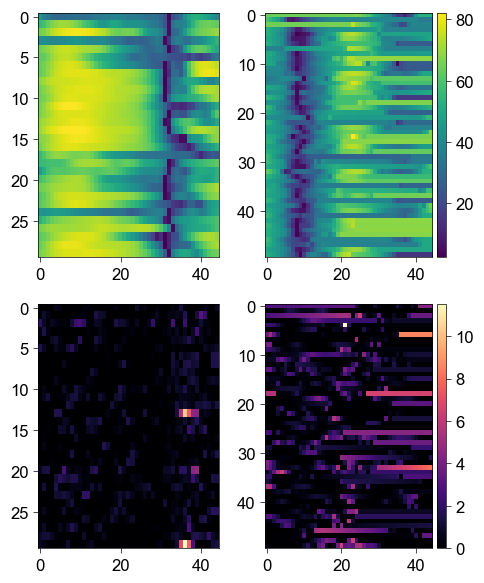

In [45]:
## Plot example trial-by-trial speed, warped, as a heat map

cell = 521#77
fig, ax = plt.subplots(2,2,figsize=(5,6))
ax[0,0].imshow(speed_data_in['set 0'], aspect = 'auto', cmap='viridis')
h1=ax[0,1].imshow(transformed_vel[best_model], aspect = 'auto', cmap='viridis')
ax[1,0].imshow(neural_data_in['set 0'][:,:,np.where(after_reward==cell)[0][0]], 
               aspect = 'auto', cmap='magma')
h2=ax[1,1].imshow(transformed_neural[best_model][:,:,np.where(after_reward==cell)[0][0]], 
                  aspect = 'auto', cmap='magma')

pt.colorbar(h1)
pt.colorbar(h2)

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_ExSpeed-ExCell226_TimeWarp" % (
        an, str(day)), extension='.pdf')

In [46]:
# Quantify with reward vs omission index from the time warp model
# Make dataframe from a fresh model run
from reward_relative import regression

exp_days = [3, 5, 7, 8, 10, 12, 14]

rgb_tuples = pt.get_anim_colors(len(anim_list))

# data per session
df = pd.DataFrame(columns=['mouse', 'day', 'n_omiss', f'RO_index_median_set{use_set[-1]}',
                           'orig_vel_mse_set0', 'orig_rew_vs_om_vel_mse_set0',
                           f'best_model_vel_mse_set{use_set[-1]}',
                           'orig_vel_mse_set1', 'orig_rew_vs_om_vel_mse_set1',
                           'best_model', 'rzone'])

# data per cell
df_cells = pd.DataFrame(columns=['mouse', 'day', 'cell_ids', 'RO_index'])

for an_i, an in enumerate(anim_list):
    for di, day in enumerate(exp_days):

        anim_colors = pt.get_anim_colors(
            list(anim_list).index(an))
        if (~np.all(np.isnan(rew_vs_omiss_index[day][an]['RO_index']))):

            df_this_day = pd.DataFrame({'mouse': an,
                                        'day': day,
                                        'n_omiss': rew_vs_omiss_index[day][an]['n_omiss'],
                                        f'RO_index_median_set{use_set[-1]}': np.nanmedian(
                                            rew_vs_omiss_index[day][an]['RO_index']),
                                        'orig_vel_mse_set0': rew_vs_omiss_vel_mse[day][an]['set 0']['original'],
                                        'orig_rew_vs_om_vel_mse_set0': rew_vs_omiss_vel_mse[day][an]['set 0'][
                                            'original_rew_vs_omiss_means'],
                                        'orig_vel_mse_set1': rew_vs_omiss_vel_mse[day][an]['set 1']['original'],
                                        'orig_rew_vs_om_vel_mse_set1': rew_vs_omiss_vel_mse[day][an]['set 1'][
                                            'original_rew_vs_omiss_means'],
                                        f'best_model_vel_mse_set{use_set[-1]}': rew_vs_omiss_vel_mse[day][an][
                                            use_set]['model'][
                                            rew_vs_omiss_index[day][an]['best_model']],
                                        'best_model': rew_vs_omiss_index[day][an]['best_model'],
                                        'rzone': multiDayData[day].rzone_label[an][use_set]
                                        },
                                       index=[0]
                                       )

            n_entries = len(rew_vs_omiss_index[day][an]['RO_index'])
            mouse_arr = np.repeat(an, n_entries)
            day_arr = np.repeat(day, n_entries)

            df_cells_this_day = pd.DataFrame({'mouse': mouse_arr,
                                              'day': day_arr,
                                              'cell_ids': rew_vs_omiss_index[day][an]['cell_ids'],
                                              'RO_index': rew_vs_omiss_index[day][an]['RO_index'],
                                              }
                                             )

        else:

            df_this_day = pd.DataFrame({'mouse': an,
                                        'day': float(day),
                                        # rew_vs_omiss_index[day][an]['n_omiss'],
                                        'n_omiss': np.nan,
                                        f'RO_index_median_set{use_set[-1]}': np.nan,
                                        'orig_vel_mse_set0': np.nan,
                                        'orig_rew_vs_om_vel_mse_set0': np.nan,
                                        'orig_vel_mse_set1': np.nan,
                                        'orig_rew_vs_om_vel_mse_set1': np.nan,
                                        f'best_model_vel_mse_set{use_set[-1]}': np.nan,
                                        'best_model': np.nan,
                                        'rzone': multiDayData[day].rzone_label[an][use_set]
                                        },
                                       index=[0]
                                       )
            continue


        df = pd.concat([df,df_this_day],
                       ignore_index=True)
        df_cells = pd.concat( [df_cells, df_cells_this_day],
                                   ignore_index=True)

In [47]:
dfs_set0_tmp = (df,df_cells)
dfs_set0 = (df,df_cells)

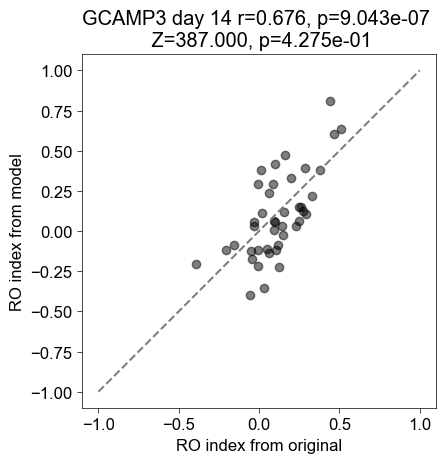

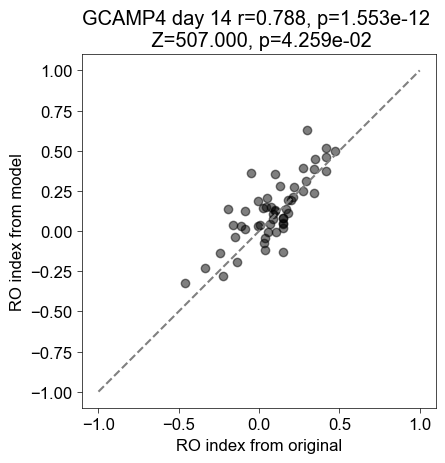

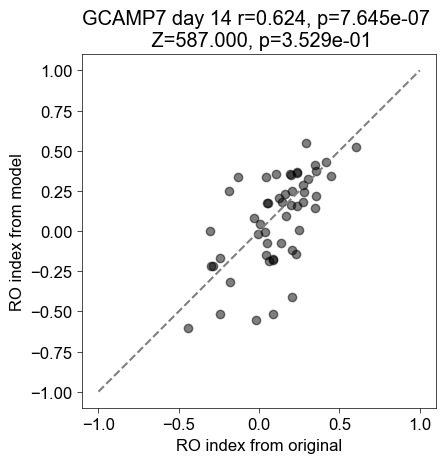

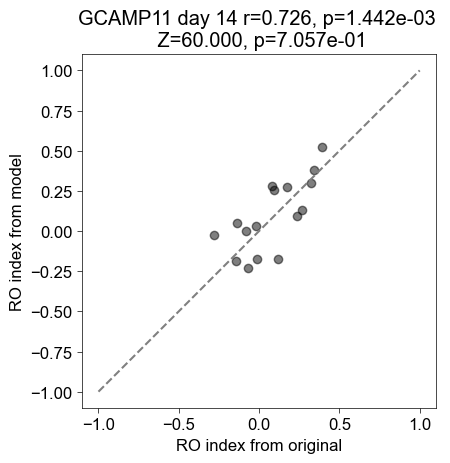

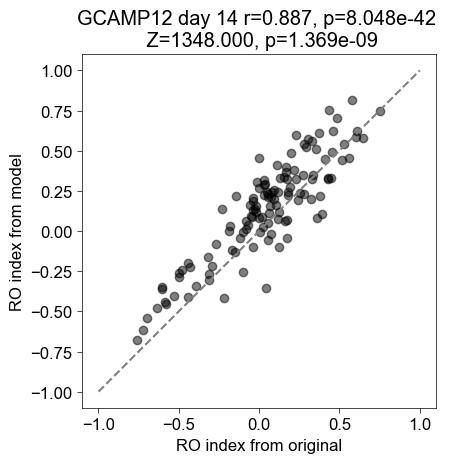

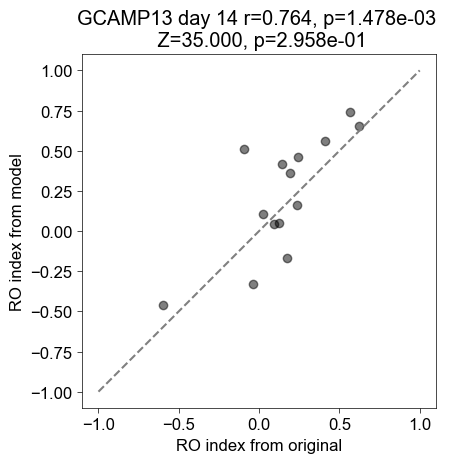

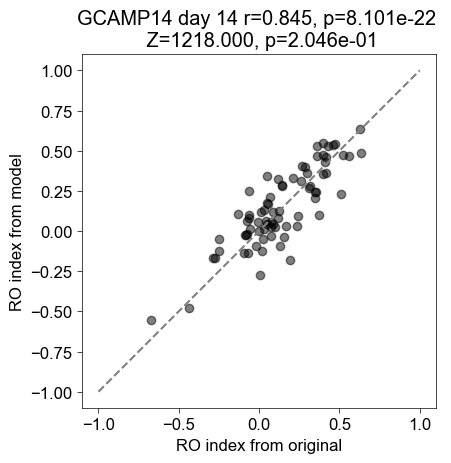

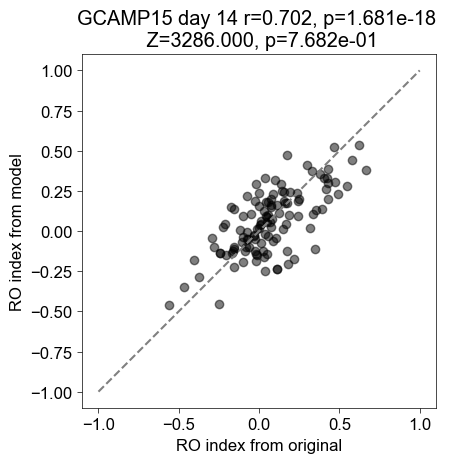

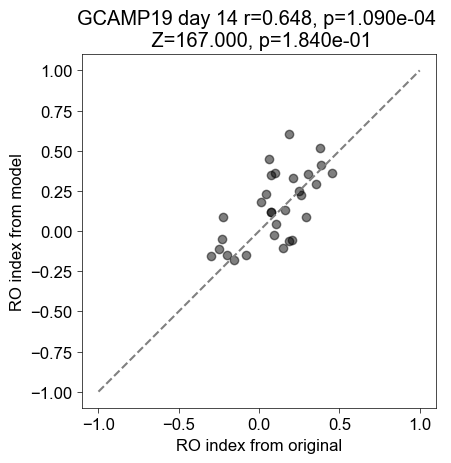

In [48]:
## correlate RO index from raw data with RO index from time-warped data
RO_r = []
RO_p = []
for day in [14]:
    for an in anim_list:
        if np.all(~np.isnan(rew_vs_omiss_index_original[day][an]['RO_index'])):
            fig, ax = plt.subplots()
            this_model_RO = dfs_set0_tmp[1]['RO_index'][(dfs_set0_tmp[1]['day']==day
                                                        ) & (dfs_set0_tmp[1]['mouse']==an)]
            ax.scatter(rew_vs_omiss_index_original[day][an]['RO_index'], this_model_RO, color='black', alpha=0.5)
            ax.plot([-1,1],[-1,1], '--', color='grey')
            r,p = sp.stats.pearsonr(rew_vs_omiss_index_original[day][an]['RO_index'], this_model_RO)
            Z,pp =sp.stats.wilcoxon(rew_vs_omiss_index_original[day][an]['RO_index'], this_model_RO)
            ax.set_title("%s day %d r=%.3f, p=%.3e \n Z=%.3f, p=%.3e" % (an, day, r, p, Z, pp))
            ax.set_ylabel('RO index from model')
            ax.set_xlabel('RO index from original')
            ax.axis('square')
            RO_r.append(r)
            RO_p.append(p)
            
            save_figures=False
            if save_figures:
                pt.savefig(fig, fig_dir, "%s_expday%d_Rew-vs-Omiss-Index_from-Model-vs-Orig_set0" % (
                    an, day))

## Save or Load previously saved model outputs

The intention here is for you to run to the model above separately for both set 0 and set 1,  \
then save the outputs to pickles after making the data frame  \
then load them back in together to do the plotting below.

[Go to loading set 1](#Set-1)

In [49]:
## SAVE dataframe!!
definitely_save = True  ## last check!
if definitely_save:
    pickle_dir = '/data/2p_data/pickle_scratch/'
    exp_days = [3,5,7,8,10,12,14]
    name = '%s_expday%s_Rew-vs-Omiss_df_set%s_pw3only' % (ut.make_anim_tag(anim_list), 
                                                          ut.make_day_tag(exp_days), use_set[-1])
    save_file = open(os.path.join(pickle_dir, name + '.pickle'), "wb")
    dill.dump((df,df_cells), save_file)
    # Close the pickle
    save_file.close()

In [21]:
## Load data from model run from set0 trials
trial_set = 0
pickle_dir = '/data/2p_data/pickle_scratch'
exp_days = [3,5,7,8,10,12,14]
load_anim_list = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
name = '%s_expday%s_Rew-vs-Omiss_df_set%s_pw3only' % (ut.make_anim_tag(load_anim_list), 
                                                      ut.make_day_tag(exp_days), trial_set)
dfs_set0 = dill.load(open(os.path.join(pickle_dir, name + '.pickle'), "rb"))

In [25]:
## Use this only if you tried different model types and want to quantify how often
## each one was the best fit
test_models = False
if test_models:
    model_range = np.arange(0,len(models)+1,1)-0.5
    fig,ax = plt.subplots()
    ax.hist(dfs_set0[0]['best_model'].values, model_range, color='grey')
    ax.set_ylabel('session count, best model')
    ax.set_xlabel('timewarp model type')
    ax.set_xticks(model_range[:-1]+0.5)
    ax.set_xticklabels(['shift', 'linear','piecewise-1', 'piecewise-2', 'piecewise-3'],rotation=30);

    save_figures = False
    if save_figures:
        pt.savefig(fig, fig_dir, "%s_expday%s_TimeWarp_BestModel_Hist_set0" % (
            ut.make_anim_tag(anim_list), ut.make_day_tag(exp_days)))

In [26]:
dfs_set0[0]['mouse'].unique()

array(['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13',
       'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19'],
      dtype=object)

In [27]:
include_ans = dfs_set0[0]['mouse'].unique()

## Plot and quantify set 0

SET 0
          W_val alternative         p_val       RBC      CLES
Wilcoxon    1.0   two-sided  1.197273e-11  0.998942  0.955926
          W_val alternative     p_val       RBC      CLES
Wilcoxon  490.0   two-sided  0.001778 -0.464481  0.376944
          W_val alternative     p_val       RBC      CLES
Wilcoxon  919.0   two-sided  0.851855  0.028027  0.535609


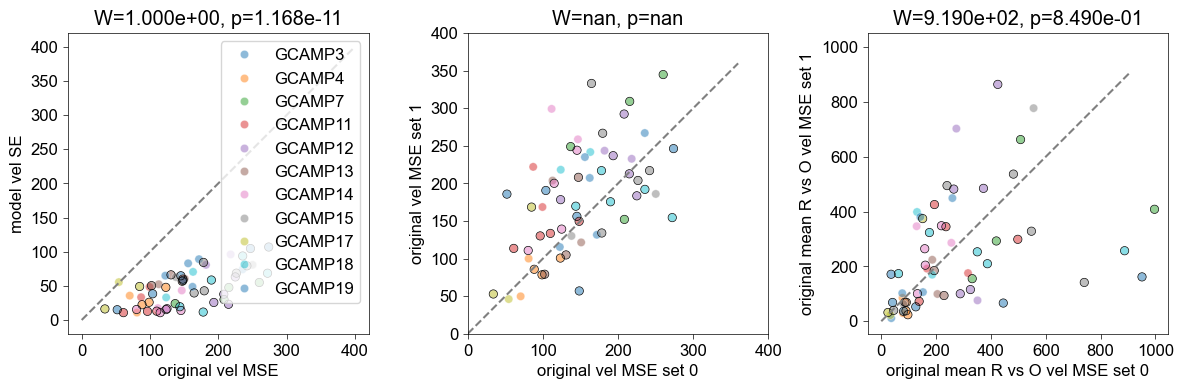

In [30]:
## Compare MSE of the model fit vs. the raw data
## Black outlines are sessions with reward at location "A" or "B"

import pingouin

fig3, ax3 = plt.subplots(1,3,figsize=(12, 4))

print('SET 0')

# limit to sessions with an A or B reward (more time on the track after reward for speed to recover)
subset0 = dfs_set0[0]['rzone'].isin(['A','B'])

sns.scatterplot(data = dfs_set0[0],
    x='orig_vel_mse_set0',
    y='best_model_vel_mse_set0',
                hue='mouse',
                palette='tab10',
                alpha=0.5,
            ax=ax3[0]
            )
sns.scatterplot(x=dfs_set0[0]['orig_vel_mse_set0'].loc[subset0],
            y=dfs_set0[0]['best_model_vel_mse_set0'].loc[subset0],
                edgecolor='k',
                facecolor='none',
                ax=ax3[0])

sns.scatterplot(data = dfs_set0[0],
    x='orig_vel_mse_set0',
    y='orig_vel_mse_set1',
                hue='mouse',
                palette='tab10',
                alpha=0.5,
            ax=ax3[1],
                legend=False
            )
sns.scatterplot(x=dfs_set0[0]['orig_vel_mse_set0'].loc[subset0],
            y=dfs_set0[0]['orig_vel_mse_set1'].loc[subset0],
                edgecolor='k',
                facecolor='none',
                ax=ax3[1])

sns.scatterplot(data = dfs_set0[0],
    x='orig_rew_vs_om_vel_mse_set0',
    y='orig_rew_vs_om_vel_mse_set1',
                hue='mouse',
                palette='tab10',
                alpha=0.5,
            ax=ax3[2],
                legend=False
            )
sns.scatterplot(x=dfs_set0[0]['orig_rew_vs_om_vel_mse_set0'].loc[subset0],
            y=dfs_set0[0]['orig_rew_vs_om_vel_mse_set1'].loc[subset0],
                edgecolor='k',
                facecolor='none',
                ax=ax3[2])

ax3[0].set(xlim=[0,400], ylim=[0,400])
ax3[0].plot([0, ax3[0].get_ylim()[1]],  [
             0, ax3[0].get_ylim()[1]], '--', color='grey')    
ax3[0].axis('square')
ax3[0].set_xlabel('original vel MSE')
ax3[0].set_ylabel('model vel SE')

ax3[1].plot([0, ax3[1].get_ylim()[1]],  [
         0, ax3[1].get_ylim()[1]], '--', color='grey')
ax3[1].axis('square')
ax3[1].set_xlabel('original vel MSE set 0')
ax3[1].set_ylabel('original vel MSE set 1')
ax3[1].set(xlim=[0,400], ylim=[0,400])

ax3[2].plot([0, ax3[2].get_ylim()[1]],  [
         0, ax3[2].get_ylim()[1]], '--', color='grey')
ax3[2].axis('square')
ax3[2].set_xlabel('original mean R vs O vel MSE set 0')
ax3[2].set_ylabel('original mean R vs O vel MSE set 1')
        
st, p = sp.stats.wilcoxon(dfs_set0[0]['orig_vel_mse_set0'],dfs_set0[0]['best_model_vel_mse_set0'])
print(pingouin.wilcoxon(dfs_set0[0]['orig_vel_mse_set0'],dfs_set0[0]['best_model_vel_mse_set0']))
ax3[0].set_title("W=%.3e, p=%.3e" % (st,p))

st, p = sp.stats.wilcoxon(dfs_set0[0]['orig_vel_mse_set0'],dfs_set0[0]['orig_vel_mse_set1'])
print(pingouin.wilcoxon(dfs_set0[0]['orig_vel_mse_set0'],dfs_set0[0]['orig_vel_mse_set1']))
ax3[1].set_title("W=%.3e, p=%.3e" % (st,p))

st, p = sp.stats.wilcoxon(dfs_set0[0]['orig_rew_vs_om_vel_mse_set0'],dfs_set0[0]['orig_rew_vs_om_vel_mse_set1'])
print(pingouin.wilcoxon(dfs_set0[0]['orig_rew_vs_om_vel_mse_set0'],dfs_set0[0]['orig_rew_vs_om_vel_mse_set1']))
ax3[2].set_title("W=%.3e, p=%.3e" % (st,p))

## reduce data set to sessions with reward zone A or B
dfs_set0_sess_AB = dfs_set0[0].loc[subset0]

save_figures=False
if save_figures:
    pt.savefig(fig3, fig_dir, "%s_expday%s_Rew-vs-Omiss-velMSEscatter_TimeWarp_set%s_pw3only_wSubsetAB" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days), use_set[-1]))
        

In [31]:
# Convert 'Category' column to Categorical with custom order
dfs_set0_sess_AB['mouse'] = pd.Categorical(dfs_set0_sess_AB['mouse'], categories=include_ans, ordered=True)
dfs_set0[0]['mouse'] = pd.Categorical(dfs_set0[0]['mouse'], categories=include_ans, ordered=True)
# Sort DataFrame by the 'Category' column
dfs_set0_sess_AB = dfs_set0_sess_AB.sort_values(by='mouse')
# dfs_set0[0] = dfs_set0[0].sort_values(by='mouse')

/tmp/ipykernel_1380320/3285499467.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_set0_sess_AB['mouse'] = pd.Categorical(dfs_set0_sess_AB['mouse'], categories=include_ans, ordered=True)


### Set 0 swarmplots

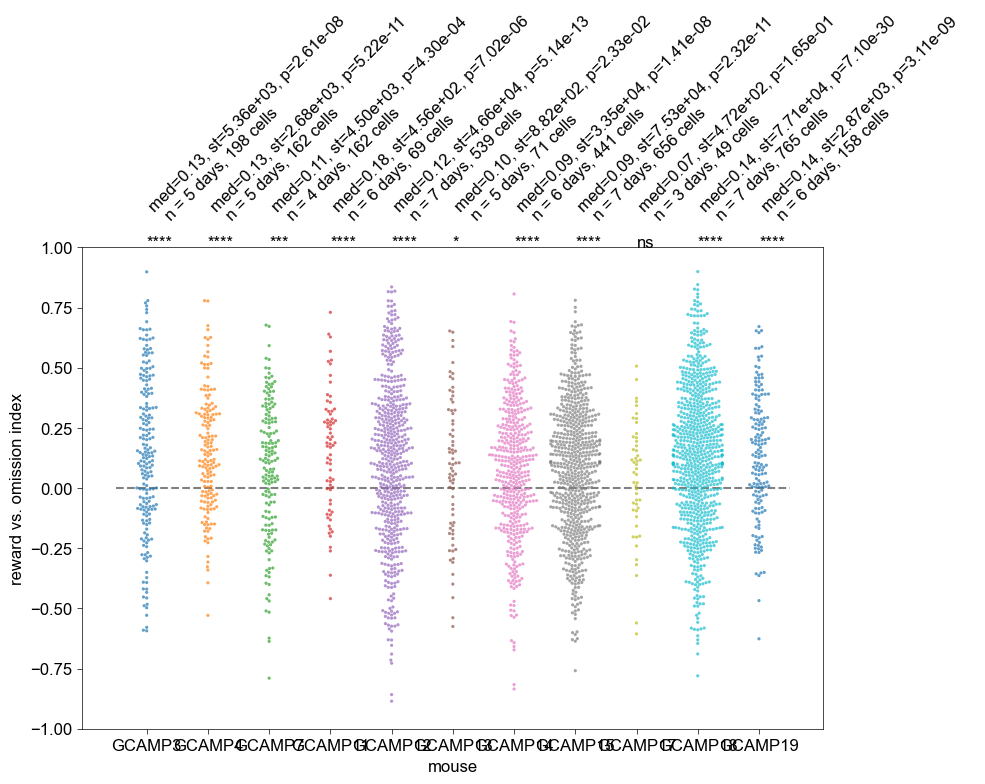

In [32]:
## Plot RO index from timewarp model, for all sessions (swarmplot in Ext. Fig. 8l)
fig, ax = plt.subplots(figsize=(10, 8))
sns.swarmplot(x="mouse", y="RO_index",  hue='mouse', data=dfs_set0[1],
              dodge=False, palette="tab10", size=2.3, alpha=0.7, ax=ax)

ax.set_ylabel('reward vs. omission index')
ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], linestyle='--', color='grey')
ax.set_ylim([-1, 1])

for an_i, an in enumerate(include_ans):
    st, p = sp.stats.wilcoxon(dfs_set0[1]['RO_index'][dfs_set0[1]['mouse'] == an])
    # print(f'{an} \n', pingouin.wilcoxon(dfs_set0[1]['RO_index'][dfs_set0[1]['mouse'] == an]))
    ptext = pt.convert_pvalue_to_asterisks(p)
    this_med = np.nanmedian(dfs_set0[1]['RO_index'][dfs_set0[1]['mouse'] == an])
    ax.text(x=an_i, y=1, s=ptext)
    ax.text(x=an_i, y=1.1, s=("med=%.2f, st=%.2e, p=%.2e \n n = %d days, %d cells" % (
        this_med,
        st, 
        p,
        len(np.unique(dfs_set0[1]['day'][dfs_set0[1]['mouse'] == an])),
        len(dfs_set0[1]['RO_index'][dfs_set0[1]['mouse'] == an]))
                             ),
        rotation=45)
save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_Rew-vs-Omiss-Index_Quant_Timewarp_AcrossDays_set0_pw3only" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))

In [33]:
# ut.write_source_csv(dfs_set0[1], "Ext8l")

In [34]:
## reduce cells df to AB sessions only
check = dfs_set0[1][['mouse','day']].apply(tuple,axis=1).isin(
    dfs_set0_sess_AB[['mouse','day']].apply(tuple,axis=1))
test = dfs_set0[1][['mouse','day']].loc[check].drop_duplicates(keep='first')
dfs_set0_cells_AB = dfs_set0[1].loc[check]

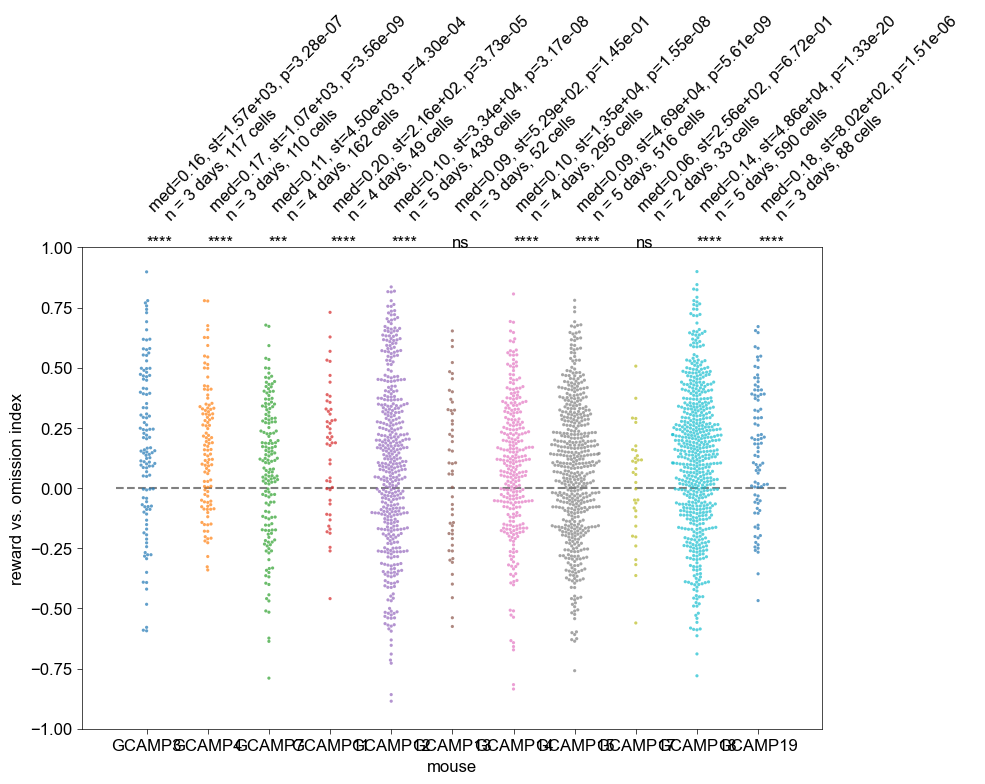

In [35]:
## AB sessions only (Fig. 6e)

fig, ax = plt.subplots(figsize=(10, 8))
sns.swarmplot(x="mouse", y="RO_index",  hue='mouse', data=dfs_set0_cells_AB,
              dodge=False, palette="tab10", size=2.3, alpha=0.7, ax=ax)

ax.set_ylabel('reward vs. omission index')
ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], linestyle='--', color='grey')
ax.set_ylim([-1, 1])

for an_i, an in enumerate(include_ans):
    if an in dfs_set0_cells_AB['mouse'].values:
        st, p = sp.stats.wilcoxon(dfs_set0_cells_AB['RO_index'][dfs_set0_cells_AB['mouse'] == an])
        ptext = pt.convert_pvalue_to_asterisks(p)
        ax.text(x=an_i, y=1, s=ptext)
        ax.text(x=an_i, y=1.1, s=("med=%.2f, st=%.2e, p=%.2e \n n = %d days, %d cells" % (
            np.nanmedian(dfs_set0_cells_AB['RO_index'][dfs_set0_cells_AB['mouse'] == an]),
            st, 
            p,
            len(np.unique(dfs_set0_cells_AB['day'][dfs_set0_cells_AB['mouse'] == an])),
            len(dfs_set0_cells_AB['RO_index'][dfs_set0_cells_AB['mouse'] == an]))
                                 ),
            rotation=45)
save_figures=False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_Rew-vs-Omiss-Index_Quant_Timewarp_AcrossDays_set0_pw3only_AB" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))

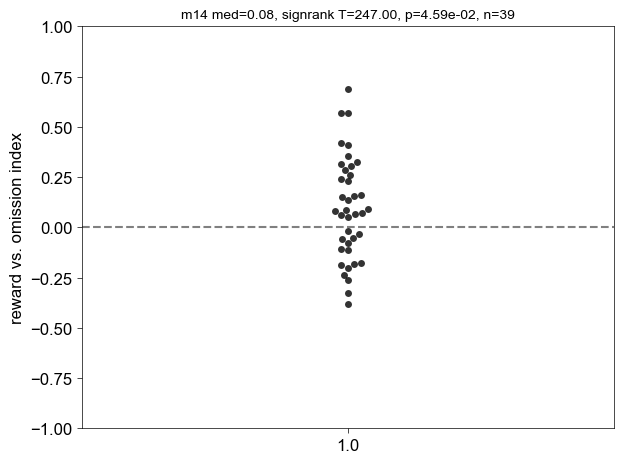

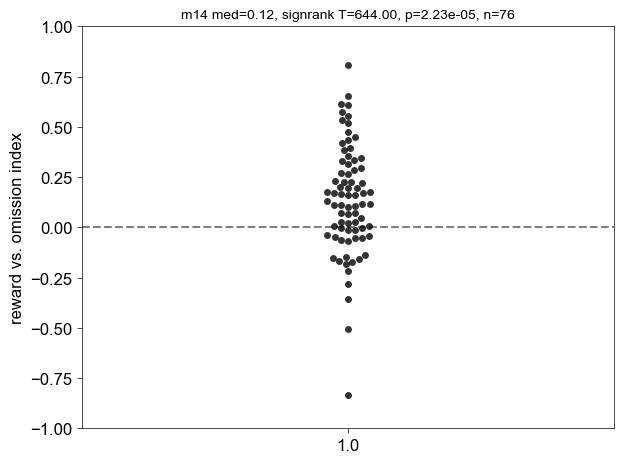

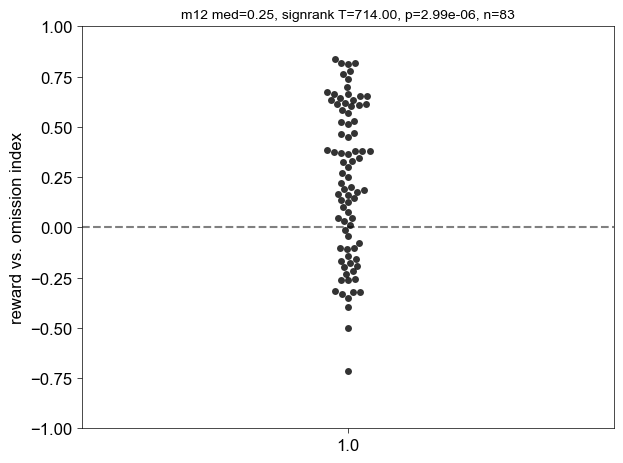

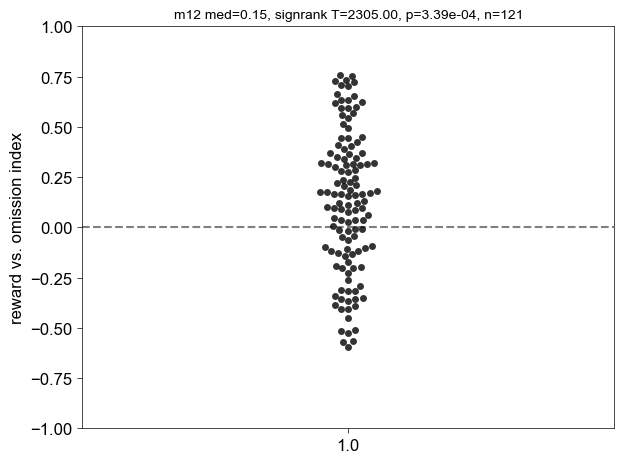

In [36]:
# Quantify with reward vs omission index per an and day -- for examples
day_list = [3,14]
an_list = ['GCAMP14', 'GCAMP12']

for an_i, an in enumerate(an_list):
    for di, day in enumerate(day_list):
        if (an in dfs_set0_cells_AB['mouse'].values) and (day in dfs_set0_cells_AB['day'].values):
        
            this_ro_index = dfs_set0_cells_AB['RO_index'][
                (dfs_set0_cells_AB['day']==day) & (dfs_set0_cells_AB['mouse']==an)]

            fig, ax = plt.subplots()
            ax.hlines(0,-0.5,2,linestyle='--', color='grey');
            sns.swarmplot(ax=ax,x=np.ones((len(this_ro_index),)), 
                          y = this_ro_index, 
                          color='black',alpha=0.8)
            ax.set_ylabel('reward vs. omission index');
            ax.set_ylim([-1,1])
            st, p = sp.stats.wilcoxon(this_ro_index)
            st, p
            ax.set_title('m%s med=%.2f, signrank T=%.2f, p=%.2e, n=%d' % (
                ut.get_mouse_number(an), np.median(this_ro_index), 
                st, p, len(this_ro_index)), fontsize=10);

            save_figures = False
            if save_figures:
                pt.savefig(fig, fig_dir, "%s_expday%d_Rew-vs-Omiss-Index-Quant_TimeWarp_set0_AB_pw3only" % (
                    an, day))

#### Run LMMs for set0

In [37]:
import statsmodels.formula.api as smf
from reward_relative import regression

In [38]:
dfs_set0[0]['day'] = dfs_set0[0]['day'].astype(float)
dfs_set0_sess_AB['day'] = dfs_set0_sess_AB['day'].astype(float)

lmm_AB = smf.mixedlm('RO_index_median_set0 ~ 1 + day*orig_rew_vs_om_vel_mse_set0*best_model_vel_mse_set0', 
                          groups='mouse', re_formula = '~1', data=dfs_set0_sess_AB).fit(reml=True)

print('LMM AB')
print(lmm_AB.summary())
print(lmm_AB.wald_test_terms())

LMM AB
                              Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           RO_index_median_set0
No. Observations:             41                Method:                       REML                
No. Groups:                   11                Scale:                        0.0104              
Min. group size:              2                 Log-Likelihood:               -26.5732            
Max. group size:              5                 Converged:                    No                  
Mean group size:              3.7                                                                 
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                         

/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/s

In [39]:
dfs_sess_to_save = dfs_set0_sess_AB[['mouse','day','orig_rew_vs_om_vel_mse_set0','best_model_vel_mse_set0',
                                    'RO_index_median_set0']]
dfs_sess_to_save['switch'] = np.array([exp_days.index(d) for d in dfs_sess_to_save['day'].values])+1
dfs_sess_to_save.head()

/tmp/ipykernel_1380320/3966246794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_sess_to_save['switch'] = np.array([exp_days.index(d) for d in dfs_sess_to_save['day'].values])+1


,mouse,day,orig_rew_vs_om_vel_mse_set0,best_model_vel_mse_set0,RO_index_median_set0,switch
0,GCAMP3,5.0,41.155249,15.033433,0.088501,2
1,GCAMP3,7.0,444.993137,64.721370,0.205012,3
3,GCAMP3,12.0,125.840876,104.609403,0.244704,6
6,GCAMP4,8.0,96.941879,47.762196,-0.001937,4
8,GCAMP4,12.0,91.397392,22.358890,0.197345,6


In [40]:
# ut.write_source_csv(dfs_sess_to_save, "Ext8j")

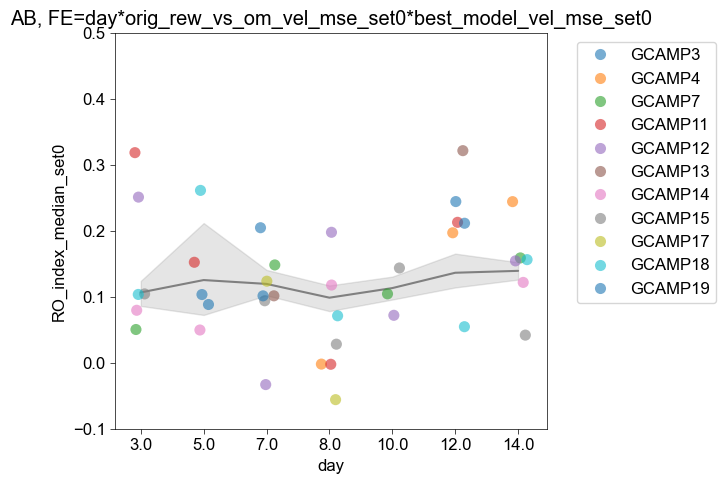

In [41]:
## Plot LMM and regression for AB set 0 sessions

fig, ax = plt.subplots(1,1, figsize = (7,5))
sns.stripplot(x='day',y='RO_index_median_set0', hue='mouse', data=dfs_set0_sess_AB, jitter=0.15, 
              palette='tab10', size=8, alpha=0.6, ax=ax)
sns.lineplot(x=dfs_set0_sess_AB['day'].rank(method='dense') - 1,
             y=lmm_AB.predict(dfs_set0_sess_AB), 
             data=dfs_set0_sess_AB,  
             color='grey', ax=ax)
ax.set_ylim([-0.1, 0.5])
ax.set_title('AB, FE=day*orig_rew_vs_om_vel_mse_set0*best_model_vel_mse_set0')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1))


save_figures=False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_Rew-vs-Omiss-Index_TimeWarp_LMM_set0_pw3only_AB" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))


# Set 1

In [43]:
## Load data from model run from set1 trials
trial_set = 1
pickle_dir = '/data/2p_data/pickle_scratch'
exp_days = [3,5,7,8,10,12,14]
load_anim_list = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
name = '%s_expday%s_Rew-vs-Omiss_df_set%s_pw3only' % (ut.make_anim_tag(load_anim_list), ut.make_day_tag(exp_days), trial_set)
dfs_set1 = dill.load(open(os.path.join(pickle_dir, name + '.pickle'), "rb"))

FileNotFoundError: [Errno 2] No such file or directory: '/data/2p_data/pickle_scratch/3-4-7-11-12-13-14-15-17-18-19_expday3-5-7-8-10-12-14_Rew-vs-Omiss_df_set1_pw3only.pickle'

In [ ]:
dfs_set1[0].head()

,mouse,day,n_omiss,RO_index_median_set1,orig_vel_mse_set0,orig_rew_vs_om_vel_mse_set0,best_model_vel_mse_set1,orig_vel_mse_set1,orig_rew_vs_om_vel_mse_set1,best_model,rzone
0,GCAMP3,3,8,0.155065,129.529823,42.560260,31.156862,67.735779,43.314055,0,A
1,GCAMP3,5,8,0.198249,52.027911,41.155249,46.517293,185.706315,68.434575,0,B
2,GCAMP3,7,6,0.147231,145.163899,444.993137,47.950907,156.086212,66.246315,0,C
3,GCAMP3,8,9,-0.008716,171.732802,36.522620,50.308823,131.578257,11.202171,0,B
4,GCAMP3,10,14,0.153248,207.655119,334.660802,96.281216,266.897714,62.487210,0,A


SET 1


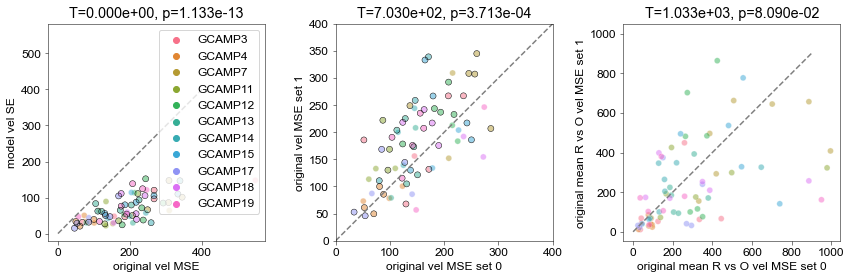

In [ ]:
## Plot Vel SSE and Reduce df to AB only

fig3, ax3 = plt.subplots(1,3,figsize=(12, 4))

print('SET 1')

subset1 = dfs_set1[0]['rzone'].isin(['A','B'])
sns.scatterplot(data = dfs_set1[0],
    x='orig_vel_mse_set1',
    y='best_model_vel_mse_set1',
                hue='mouse',
                alpha=0.5,
            ax=ax3[0]
            )
sns.scatterplot(x=dfs_set1[0]['orig_vel_mse_set1'].loc[subset1],
            y=dfs_set1[0]['best_model_vel_mse_set1'].loc[subset1],
                edgecolor='k',
                facecolor='none',
                ax=ax3[0])

sns.scatterplot(data = dfs_set1[0],
    x='orig_vel_mse_set0',
    y='orig_vel_mse_set1',
                hue='mouse',
                alpha=0.5,
            ax=ax3[1],
                legend=False
            )
sns.scatterplot(x=dfs_set1[0]['orig_vel_mse_set0'].loc[subset1],
            y=dfs_set1[0]['orig_vel_mse_set1'].loc[subset1],
                edgecolor='k',
                facecolor='none',
                ax=ax3[1])

sns.scatterplot(data = dfs_set1[0],
    x='orig_rew_vs_om_vel_mse_set0',
    y='orig_rew_vs_om_vel_mse_set1',
                hue='mouse',
                alpha=0.5,
            ax=ax3[2],
                legend=False
            )
       

ax3[0].set(xlim=[0,400], ylim=[0,400])
ax3[0].plot([0, ax3[0].get_ylim()[1]],  [
             0, ax3[0].get_ylim()[1]], '--', color='grey')    
ax3[0].axis('square')
ax3[0].set_xlabel('original vel MSE')
ax3[0].set_ylabel('model vel SE')

ax3[1].plot([0, ax3[1].get_ylim()[1]],  [
         0, ax3[1].get_ylim()[1]], '--', color='grey')
ax3[1].axis('square')
ax3[1].set_xlabel('original vel MSE set 0')
ax3[1].set_ylabel('original vel MSE set 1')
ax3[1].set(xlim=[0,400], ylim=[0,400])

ax3[2].plot([0, ax3[2].get_ylim()[1]],  [
         0, ax3[2].get_ylim()[1]], '--', color='grey')
ax3[2].axis('square')
ax3[2].set_xlabel('original mean R vs O vel MSE set 0')
ax3[2].set_ylabel('original mean R vs O vel MSE set 1')
# ax3[2].set(xlim=[0,400], ylim=[0,400])
        
st, p = sp.stats.wilcoxon(dfs_set1[0]['orig_vel_mse_set1'],dfs_set1[0]['best_model_vel_mse_set1'])
ax3[0].set_title("T=%.3e, p=%.3e" % (st,p))

st, p = sp.stats.wilcoxon(dfs_set1[0]['orig_vel_mse_set0'],dfs_set1[0]['orig_vel_mse_set1'])
ax3[1].set_title("T=%.3e, p=%.3e" % (st,p))

st, p = sp.stats.wilcoxon(dfs_set1[0]['orig_rew_vs_om_vel_mse_set0'],dfs_set1[0]['orig_rew_vs_om_vel_mse_set1'])
ax3[2].set_title("T=%.3e, p=%.3e" % (st,p))

dfs_set1_sess_AB = dfs_set1[0].loc[subset1]

### Swarmplots for set 1 trials

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/seaborn/categorical.py:3544: UserWarning: 5.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


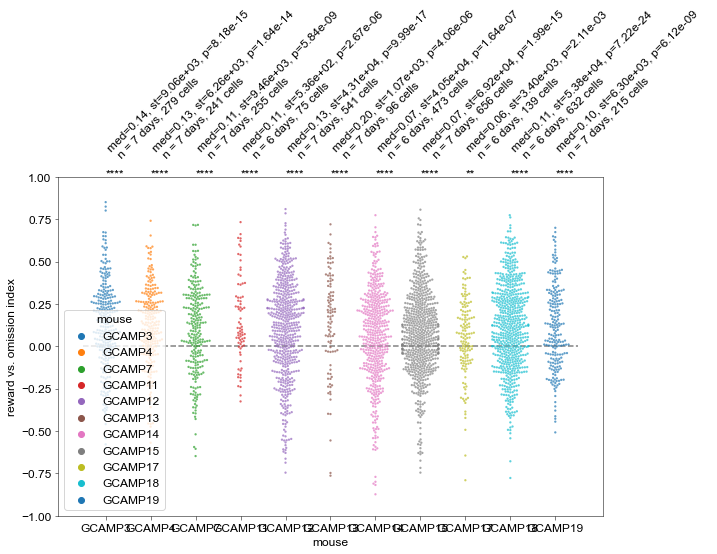

In [ ]:
## All sessions
include_ans = dfs_set1[0]['mouse'].unique()

fig, ax = plt.subplots(figsize=(10, 8))
sns.swarmplot(x="mouse", y="RO_index",  hue='mouse', data=dfs_set1[1],
              dodge=False, palette="tab10", size=2.3, alpha=0.7, ax=ax)

ax.set_ylabel('reward vs. omission index')
ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], linestyle='--', color='grey')
ax.set_ylim([-1, 1])

for an_i, an in enumerate(include_ans):
    st, p = sp.stats.wilcoxon(dfs_set1[1]['RO_index'][dfs_set1[1]['mouse'] == an])
    ptext = pt.convert_pvalue_to_asterisks(p)
    ax.text(x=an_i, y=1, s=ptext)
    ax.text(x=an_i, y=1.1, s=("med=%.2f, st=%.2e, p=%.2e \n n = %d days, %d cells" % (
        np.nanmedian(dfs_set1[1]['RO_index'][dfs_set1[1]['mouse'] == an]),
        st, 
        p,
        len(np.unique(dfs_set1[1]['day'][dfs_set1[1]['mouse'] == an])),
        len(dfs_set1[1]['RO_index'][dfs_set1[1]['mouse'] == an]))
                             ),
        rotation=45)
save_figures=False  
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_Rew-vs-Omiss-Index_Quant_Timewarp_AcrossDays_set1_pw3only" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))

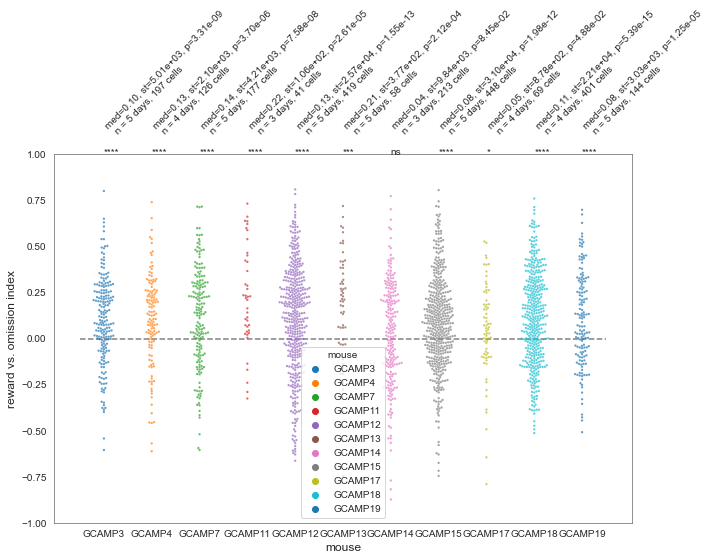

In [ ]:
## AB only sessions (Ext. Fig. 8k)
check1 = dfs_set1[1][['mouse','day']].apply(tuple,axis=1).isin(dfs_set1_sess_AB[['mouse','day']].apply(tuple,axis=1))
dfs_set1_cells_AB = dfs_set1[1].loc[check1]

fig, ax = plt.subplots(figsize=(10, 8))
sns.swarmplot(x="mouse", y="RO_index",  hue='mouse', data=dfs_set1_cells_AB,
              dodge=False, palette="tab10", size=2.3, alpha=0.7, ax=ax)

ax.set_ylabel('reward vs. omission index')
ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], linestyle='--', color='grey')
ax.set_ylim([-1, 1])

for an_i, an in enumerate(include_ans):
    if an in dfs_set1_cells_AB['mouse'].values:
        st, p = sp.stats.wilcoxon(dfs_set1_cells_AB['RO_index'][dfs_set1_cells_AB['mouse'] == an])
        ptext = pt.convert_pvalue_to_asterisks(p)
        ax.text(x=an_i, y=1, s=ptext)
        ax.text(x=an_i, y=1.1, s=("med=%.2f, st=%.2e, p=%.2e \n n = %d days, %d cells" % (
            np.nanmedian(dfs_set1_cells_AB['RO_index'][dfs_set1_cells_AB['mouse'] == an]),
            st, 
            p,
            len(np.unique(dfs_set1_cells_AB['day'][dfs_set1_cells_AB['mouse'] == an])),
            len(dfs_set1_cells_AB['RO_index'][dfs_set1_cells_AB['mouse'] == an]))
                                 ),
            rotation=45)
    
if save_figures:
    pt.savefig(fig, fig_dir, "%s_expday%s_Rew-vs-Omiss-Index_Quant_Timewarp_AcrossDays_set1_pw3only_AB" % (
        ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))

In [ ]:
# ut.write_source_csv(dfs_set1_cells_AB, "Ext8k")

writing /data/2P/source_data/FigExt8k.csv
